<a href="https://colab.research.google.com/github/yianchen903/my-project/blob/main/Minimization_Pb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **SIA equation (Fenics)**

**Import Fenics**

In [ ]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh" import dolfin

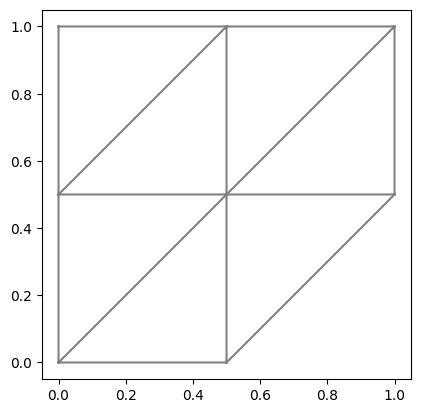

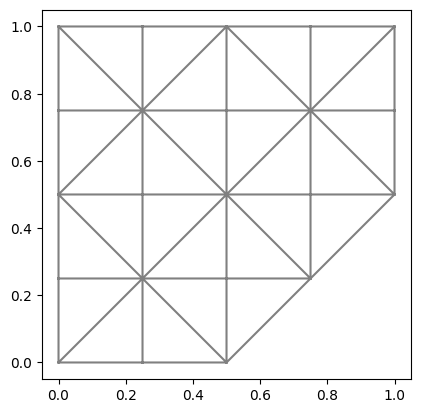

In [ ]:
from dolfin import *
import matplotlib.pyplot as plt
# 初始化網格
mesh = Mesh()
editor = MeshEditor()
editor.open(mesh, "triangle", 2, 2)  # 2D 三角形網格

# 定義節點數量和單元數量
editor.init_vertices(9)  # 9 個頂點
editor.init_cells(7)     # 8 個三角形單元

# 添加頂點 (x, y) 座標
vertices = [
    (0, 0), (0.5, 0), (1, 0),    # 底邊
    (0, 0.5), (0.5, 0.5), (1, 0.5), # 中間
    (0, 1), (0.5, 1), (1, 1)     # 上邊
]

for i, vertex in enumerate(vertices):
    editor.add_vertex(i, Point(*vertex))

# 添加三角形單元
cells = [ [1, 4, 5],
    [0, 1, 4], [0, 3, 4],
    [3, 4, 7], [3, 6, 7],
    [4, 5, 8], [4, 7, 8]
]

for i, cell in enumerate(cells):
    editor.add_cell(i, cells[i])

# 關閉編輯器
editor.close()

# 可視化網格
plot(mesh)
plt.show()
mesh = refine(mesh)
plot(mesh)
# mesh = refine(mesh)
# plot(mesh)

-------------------------

Sympi

In [ ]:
import sympy as sp
x, y, t = sp.symbols('x y t')


r = (x**2+y**2)**0.5




Hex2D = sp.sin(sp.pi*x)*sp.sin(sp.pi*y)
#-------------------
u = Hex2D

u_t = u.diff(t)
u_x = u.diff(x)
u_y = u.diff(y)

# au = 1
# au = gamma * u**5 * (u_x**2 + u_y**2) #shallow ice approximation
au = ((u_x**2 + u_y**2)**0.5)**(2.0)
# au = u**3
# au = u*u
# au = -u*u

u1 = au * u_x
u2 = au * u_y

f =  u_t - (u1.diff(x) + u2.diff(y))
f_simplified = sp.simplify(f)

print("aH = ", au)
# print("aH*H_x = ", u1)
# print("aH*H_y = ", u2)
print("Hex.diff(x) = ", u_x)
print("Hex.diff(y) = ", u_y)
print("f(x, u) = ", f_simplified)

**Solving the Minimization Problem---CG**

**p-Laplace equation**

\begin{equation}
\begin{split}
& -\operatorname{div} \mathbb{A}(\nabla u)=\mathbf{f} \text { in } \Omega, \\
& u=u_D \quad \text { on } \Gamma_D, \\
& \mathcal{A}(\nabla u) \mathbf{n}=\mathbf{a}_N \quad \text { on } \Gamma_N, \\
&
\end{split}
\end{equation}

where $\mathbb{A}: \mathbb{R}^d \mapsto \mathbb{R}^d$ is defined as $\mathcal{A}(\boldsymbol{\tau}):=|\boldsymbol{\tau}|^{p-2} \boldsymbol{\tau}$


$\Gamma_D = ∂Ω$

$\Gamma_N = ∅$

consider $p=2,3,4$, with smooth case

test1
$u_{ex} = e^{-x^2-y^2} ,\ u=u_D  \text { on } \Gamma_D$

test2
$u_{ex} = sin(\pi x)sin(\pi y), \ u=u_D = 0 \text { on } \Gamma_D$

test3
$u_{ex}=\frac{p-1}{p}\left(\frac{1}{2}\right)^{\frac{1}{p-1}}\left(1-r^{\frac{p}{p-1}}\right),  \ u=u_D = 0 \text { on } \Gamma_D$

test4
$u_{ex}=r^{\frac{p-2}{p-1}},p > 2, \ u=u_D \text { on } \Gamma_D $

\

??????????\
$w_n, u_n \in V_0^h=\left\{\chi \in V^h: \chi\left(x\right)=0, \quad\right.$ for all vertices $\left.x \in \partial \Omega\right\}$

where  $V^h = \{\chi \mid \left.\chi\right|_K \in P_l \ , \ K \in T^h\}$

$\|w_n\|$=1 \

$u_D \neq 0 \text { on } \Gamma_D$

??????????

In [ ]:
from fenics import *
from dolfin import *
from mshr import *
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import math


def grad_norm(u):
    return sqrt(inner(grad(u), grad(u)))

x, y = sp.symbols('x[0] x[1] ')


p = 4.0 # p-Laplace
test = 3 # test pb
tol = 0.1
pdeg = 1 # degree
size = 20

# Exact sol / source term f

if p==2:
  if test==1:
    tol = 0.1
    mesh = RectangleMesh(Point(0+tol, 0+tol), Point(1, 1), size, size)
    f = 4*(-x**2 - y**2 + 1)*sp.exp(-x**2 - y**2)
    f = Expression(sp.printing.ccode(f), degree=3)
    uex = Expression("exp(-1*pow(x[0],2.0)-1*pow(x[1],2.0))",degree=3)
    Lex = Expression(("-2*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " -2*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3)
    Aex = Expression(("-2*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " -2*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3)
    Coe = Constant(1.0)
  if test==2:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    f = Expression(" 2*pow(pi,2)*sin(pi*x[0])*sin(pi*x[1])", degree=5,pi=math.pi)
    uex = Expression(" sin(pi*x[0])*sin(pi*x[1]) ",degree=5,pi=math.pi)
    Lex = Expression((" pi*sin(pi*x[1])*cos(pi*x[0]) "," pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi)
    Aex = Expression((" pi*sin(pi*x[1])*cos(pi*x[0]) "," pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi)
    Coe = Constant(1.0)
  else:
    domain = Circle(Point(0, 0), 1, 50)
    mesh = generate_mesh(domain, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=5)
    uex = Expression("(1.0/4)*(1-pow(r,2.0))", degree=5,r=r)
    Lex = Expression(("-0.5*x[0] " , "-0.5*x[1]"),degree=5)
    Coe = Constant(1.0)
    Aex = Expression(("Coe*-0.5*x[0] " , "Coe*-0.5*x[1]"),degree=5,Coe=Coe)
    f = Constant(1.0)
else:
  if test==1:
    tol = 0.1
    mesh = RectangleMesh(Point(0+tol, 0+tol), Point(1, 1), size, size)
    f =  2*(8.0*((x**2 + y**2)*sp.exp(-2*x**2 - 2*y**2))**1.0*(-x**2 - y**2 + 1)*sp.exp(3*x**2 + 3*y**2) - (x**2 + y**2)*(16.0*x**2 + 16.0*y**2 - 8.0)*sp.exp(x**2 + y**2))*sp.exp(-4*x**2 - 4*y**2)
    f = Expression(sp.printing.ccode(f), degree=3)
    uex = Expression("exp(-1*pow(x[0],2)-1*pow(x[1],2))",degree=3)
    Lex = Expression(("-2*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " -2*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3)
    Coe = ((4*x**2*sp.exp(-2*x**2 - 2*y**2) + 4*y**2*sp.exp(-2*x**2 - 2*y**2))**0.5 )**2.0
    Coe = Expression(sp.printing.ccode(Coe), degree=3)
    Aex = Expression(("Coe*(-2)*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " Coe*(-2)*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3,Coe = Coe)
  elif test==2:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    uex = Expression(" sin(pi*x[0])*sin(pi*x[1])",degree=3,pi=math.pi)
    Lex = Expression((" pi*sin(pi*x[1])*cos(pi*x[0]) "," pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=3,pi=math.pi)
    Coe = Expression("pow((pow(pi,2)*pow(sin(pi*x[0]),2)*pow(cos(pi*x[1]),2) + pow(pi,2)*pow(sin(pi*x[1]),2)*pow(cos(pi*x[0]),2)),1.0)", degree=3,pi=math.pi)
    Aex = Expression((" Coe*pi*sin(pi*x[1])*cos(pi*x[0]) "," Coe*pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=3,pi=math.pi,Coe=Coe)
    f = Expression(" (0.5*pow(pi,4.0)*(-cos(pi*(2*x[0] - 2*x[1])) - cos(pi*(2*x[0] + 2*x[1])) + 2) - 2.0*pow(pi,4)*pow(cos(pi*x[0]),2)*cos(2*pi*x[1]) - 2.0*pow(pi,4)*cos(2*pi*x[0])*pow(cos(pi*x[1]),2))*sin(pi*x[0])*sin(pi*x[1])", degree=3,pi=math.pi)
  elif test==3:
    domain = Circle(Point(0, 0), 1, 50)
    mesh = generate_mesh(domain, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=5)
    uex = Expression("(3.0/4)*pow(1.0/2,1.0/3)*(1-pow(r,4.0/3))", degree=5,r=r)
    Lex = Expression(("-0.7937005259841*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333) " , " -0.7937005259841*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333)"),degree=5)
    Coe = Expression("0.629960524947437*pow((pow(x[0],2)/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) + pow(x[1],2)/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)),1.0)", degree=5,r=r)
    Aex = Expression(("Coe*-0.707106781186547*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.25) " , " Coe*-0.707106781186547*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.25)"),degree=5,Coe=Coe)
    f = 0.666666666666667/(x**2 + y**2)**4.44089209850063e-16 + 0.333333333333333
    f = Expression(sp.printing.ccode(f), degree=3)
  else:
    mesh = RectangleMesh(Point(0+tol, 0+tol), Point(1, 1), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=3)
    uex = Expression("pow(r,(p-2)/(p-1))",degree=3,r=r,p=p)
    Lex = Expression(("0.666666666666667*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) " , " 0.666666666666667*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)"),degree=3)
    Coe = 0.444444444444444*(x**2/(x**2 + y**2)**1.33333333333333 + y**2/(x**2 + y**2)**1.33333333333333)**1.0
    Coe = Expression(sp.printing.ccode(Coe), degree=3)
    Aex = Expression(("Coe*0.5*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.75) " , "Coe* 0.5*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.75)"),degree=3,Coe=Coe)
    f = 1.66533453693773e-16/(x**2 + y**2)**1.0
    f = Expression(sp.printing.ccode(f), degree=3)


V1 = FunctionSpace(mesh, "CG", pdeg)
V2 = VectorFunctionSpace(mesh, "CG", pdeg)
V3 = VectorFunctionSpace(mesh, "CG", pdeg)


# ff = project(f,V1)
# plt.figure()
# ccc = plot(ff)
# plt.colorbar(ccc)
# plt.title('f')
# plt.legend()
# plt.show()

#examine the degeneracy
# Coeplot = project(Coe,V1)
# plt.figure()
# c0 = plot(Coeplot)
# plt.colorbar(c0)
# plt.title('Coe')
# plt.legend()
# plt.show()


 
iter=0:
Before doing line search :wnorm = 0.4714201559087668 Ju0 = -0.2569544208176517 Jzn = -0.3775741573112909 Jw = 0.8454858451218659 Juex = -0.5614841706705418 
****line search iter=0: stepsize=1.0000000000000000 ****
After doing line search: 
iter_stepsize=1:
stepsize=1.0000000000000000 Jz0=-0.2569544208176517 Jzn=-0.3775741573112909 RHS=-0.2571007804746991 Juex=-0.5614841706705418
error_iter=0.4714201559087670 error_ex=0.2501963222616190
 
iter=1:
Before doing line search :wnorm = 2.2871827356276682 Ju0 = -0.3775741573112909 Jzn = 52646.4908762263730750 Jw = 52531.5019058811230934 Juex = -0.5614841706705418 
****line search iter=0: stepsize=1.0000000000000000 ****
****line search iter=1: stepsize=0.4000000000000000 ****
****line search iter=2: stepsize=0.1600000000000000 ****
****line search iter=3: stepsize=0.0640000000000000 ****
****line search iter=4: stepsize=0.0256000000000000 ****
After doing line search: 
iter_stepsize=5:
stepsize=0.0256000000000000 Jz0=-0.3775741573112

Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_98c6ebc1223f31d223e2c592b3d381a817c3da5c

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    7
  Coefficients:              '[f_1840, f_1857, f_1897, f_1979, f_2065, f_2149, f_223
                             2]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 2
INFO:FFC:  quadrature_degree: 2
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0336308 seconds.

INFO:FFC:Compiler stage 

error_iter=0.0221984219946005 error_ex=0.0146612935078560
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_88320364be91e68573986604c6f9a30643a317b2

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    9
  Coefficients:              '[f_1827, f_1857, f_1897, f_1979, f_2065, f_2149, f_223
                             2, f_2286, f_2291]'
  Unique elements:           'CG1(?,?), CG3(?,?), R0(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), CG3(?,?), R0(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> d

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_5b71e4d1cd4d60cabfaf29c651b4d3b3204c5ec8

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      0
  Arguments:                 '()'
  Number of coefficients:    22
  Coefficients:              '[f_1827, f_1857, f_1897, f_1979, f_2065, f_2149, f_223
                             2, f_2314, f_2400, f_2483, f_2566, f_2649, f_2732, f_28
                             15, f_2897, f_2980, f_3063, f_3145, f_3228, f_3311, f_3
                             394, f_3476]'
  Unique elements:           'CG3(?,?), CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG3(?,?), CG1(?,?), Vector<2 x CG1(?,?)>'
  
IN

After doing line search: 
iter_stepsize=2:
stepsize=0.4000000000000000 Jz0=-0.5620085079540068 Jzn=-0.5620085079540070 RHS=-0.5620085079540068 Juex=-0.5614841706705418
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_fa0f1e3993fe783e40bc70cbda9e55fb0e30544c

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    22
  Coefficients:              '[f_1840, f_1857, f_1897, f_1979, f_2065, f_2149, f_223
                             2, f_2314, f_2400, f_2483, f_2566, f_2649, f_2732, f_28
                             15, f_2897, f_2980, f_3063, f_3145, f_3228, f_3311, f_3
                             394, f_3476]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   aut

error_iter=0.0000000373681675 error_ex=0.0005165928023781
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_71f94ce5bdb67ae20232e956f8ae2d5a4fc0f353

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    21
  Coefficients:              '[f_1857, f_1897, f_1979, f_2065, f_2149, f_2232, f_231
                             4, f_2400, f_2483, f_2566, f_2649, f_2732, f_2815, f_28
                             97, f_2980, f_3063, f_3145, f_3228, f_3311, f_3394, f_3
                             476]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> de

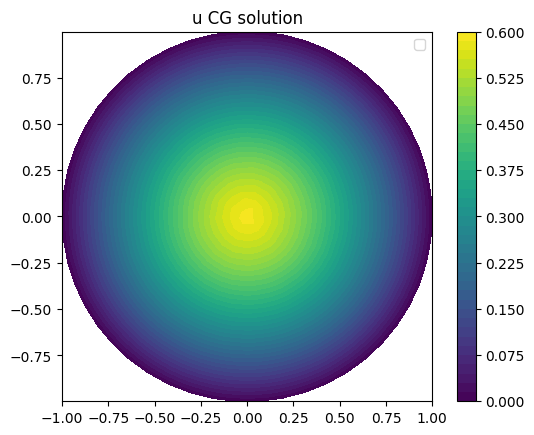



p = 4 
u : degree 1 , q : degree 1, sigma : degree 1
mesh = 20 x 20 x 2
|u-uh|_{L2} 	 |q-qh|_{L2} 	 |sigma-sigma_h|_{L2}
0.0005165928023780 	  0.0123646623343748 	  0.0926834549258432




In [ ]:
def J(x):
    return assemble(1/p*sqrt(inner(grad(x), grad(x)))**p*dx  - f*x*dx)

# Solving by gradient descent

uex = project(uex,V1)
Juex = assemble(1/p*sqrt(inner(grad(uex), grad(uex)))**p*dx  - f*uex*dx)

# u0 = project(Expression("uex ", degree=5,uex=uex), V1)
u0 = project(Expression("1-r ", degree=5,r=r), V1)
# u0 = project(Expression("(x[0]-1)*x[0]*(x[1]-1)*x[1]", degree=5,uex=uex), V1)

eps = 1.0
tol = 1.0e-8
iter = 0
maxiter = 20
t = np.arange(0, 1.1, 0.1)

while eps > tol and iter < maxiter:
  u = Function(V1)
  v = TestFunction(V1)
  alpha = 1


# Find the steepest direction
  w = TrialFunction(V1)

  w = Function(V1)
  uD = Constant(0.0)
  # uD = uex
  bc = DirichletBC(V1, uD, "on_boundary")

  dJdu = pow(sqrt(inner(grad(u0), grad(u0))),p-2)*inner(grad(u0),grad(v))*dx  - f*v*dx
  D = pow(Constant(0.0001) + sqrt(inner(grad(u0), grad(u0))),p-2)*inner(grad(w),grad(v))*dx
  F = D + dJdu

  solve(F == 0  , w, bc)
  w = project(w, V1)
  wnorm = sqrt( assemble(w*w*dx) )

  znn = u0+alpha*w
  Ju0 = assemble(1/p*sqrt(inner(grad(u0), grad(u0)))**p*dx  - f*u0*dx)
  Jw = assemble(1/p*sqrt(inner(grad(w), grad(w)))**p*dx  - f*w*dx)
  Jznn = assemble(1/p*sqrt(inner(grad(znn), grad(znn)))**p*dx  - f*znn*dx)
  print(" ")
  print("iter=%d:" %iter )
  print("Before doing line search :wnorm = %.16f Ju0 = %.16f Jzn = %.16f Jw = %.16f Juex = %.16f " %(wnorm, Ju0, Jznn, Jw, Juex))

# Backtrack line search
  tol_l = 1e-6
  c2 = 1e-4
  c1 = 0.4
  stepsize = alpha
  starting = u0
  direction = w
  Jz0 = assemble(1/p*sqrt(inner(grad(starting), grad(starting)))**p*dx  - f*starting*dx)
  dJdz0 = assemble(pow(sqrt(inner(grad(starting), grad(starting))),p-2)*inner(grad(starting),grad(direction))*dx  - f*direction*dx)
  iter_l = 0
  zn = Function(V1)

  # phiv = []
  # condv = []
  # for i in range(11):
  #   Phi = J(starting+(i/10.0)*direction)
  #   cond = J(starting)+c2*(i/10.0)*dJdz0
  #   phiv.append(Phi)
  #   condv.append(cond)

  # condv = np.array(condv)
  # phiv = np.array(phiv)
  # plt.plot(t, phiv, marker='o',label='J(z0 + alpha * wn)')
  # plt.plot(t, condv, marker='o',label='J(z0) + c2 * alpha * dJdz0')
  # plt.xlabel('alpha')
  # plt.ylabel('phi(alpha)')
  # plt.legend()
  # plt.title('phi(alpha) = J(z0 + alpha * wn)')
  # plt.grid(True)
  # plt.show()


  while stepsize>tol_l:
    print("****line search iter=%d: stepsize=%.16f ****"%(iter_l,stepsize))
    iter_l  = iter_l + 1
    zn = starting+stepsize*direction
    Jzn =  assemble(1/p*sqrt(inner(grad(zn), grad(zn)))**p*dx  - f*zn*dx)

    if Jzn < Jz0+c2*stepsize*dJdz0:
      break
    else:
      stepsize = c1*stepsize



  print("After doing line search: ")
  print("iter_stepsize=%d:" %iter_l)
  print ("stepsize=%.16f Jz0=%.16f Jzn=%.16f RHS=%.16f Juex=%.16f" %(stepsize, Jz0, Jzn, Jz0+c2*stepsize*dJdz0, Juex))


  alpha = stepsize
  u = u0 + alpha * w

  # u_er = project(u-u0, V1)
  u_er = project(w, V1)
  u_exer = project(u-uex, V1)
  u_L2iter = sqrt(assemble(inner(u_er,u_er)*dx))
  uex_L2iter = sqrt(assemble(inner(u_exer,u_exer)*dx))
  eps = u_L2iter
  eps_ex =  uex_L2iter
  print ("error_iter=%.16f error_ex=%.16f" %( eps, eps_ex))
  u0 = u
  iter = iter + 1



u = project(u, V1)
L = project(grad(u), V2)
A = pow(sqrt(inner(grad(u), grad(u))),p-2)*grad(u)
A = project(A, V3)

# plt.figure()
# c1 = plot(L)
# plt.colorbar(c1)
# plt.title('q(grad u) CG solution ')
# plt.legend()
# plt.show()

# plt.figure()
# c2 = plot(A)
# plt.colorbar(c2)
# plt.title('sigma(grad u) CG solution')
# plt.legend()
# plt.show()

plt.figure()
c3 = plot(u)
plt.colorbar(c3)
plt.title('u CG solution')
plt.legend()
plt.show()


uer = project(u-uex, V1)
Ler = project(L-Lex, V2)
Aer = project(A-Aex, V3)

L_L2er = sqrt( assemble(inner(Ler,Ler)*dx) )
A_L2er = sqrt( assemble(inner(Aer,Aer)*dx) )
u_L2er = sqrt( assemble(uer*uer*dx) )



print ("\n")
print("p = %d " %p)
print("u : degree %d , q : degree %d, sigma : degree %d" %(pdeg,pdeg,pdeg))
print("mesh = %d x %d x 2" %(size,size))
print ("|u-uh|_{L2} \t |q-qh|_{L2} \t |sigma-sigma_h|_{L2}")
print ("%.16f \t  %.16f \t  %.16f" % (u_L2er, L_L2er, A_L2er))
print ("\n")


**Solving the Minimization Problem---LDG**

**p-Laplace equation**

\begin{equation}
\begin{split}
& -\operatorname{div} \mathbb{A}(\nabla u)=\mathbf{f} \text { in } \Omega, \\
& u=u_D \quad \text { on } \Gamma_D, \\
& \mathcal{A}(\nabla u) \mathbf{n}=\mathbf{a}_N \quad \text { on } \Gamma_N, \\
&
\end{split}
\end{equation}

where $\mathbb{A}: \mathbb{R}^d \mapsto \mathbb{R}^d$ is defined as $\mathcal{A}(\boldsymbol{\tau}):=|\boldsymbol{\tau}|^{p-2} \boldsymbol{\tau}$


$\Gamma_D = ∂Ω$

$\Gamma_N = ∅$

consider $p=2,3,4$, with smooth case

test1
$u_{ex} = e^{-x^2-y^2} ,\ u=u_D  \text { on } \Gamma_D$

test2
$u_{ex} = sin(\pi x)sin(\pi y), \ u=u_D = 0 \text { on } \Gamma_D$

test3
$u_{ex}=\frac{p-1}{p}\left(\frac{1}{2}\right)^{\frac{1}{p-1}}\left(1-r^{\frac{p}{p-1}}\right),  \ u=u_D = 0 \text { on } \Gamma_D$

test4
$u_{ex}=r^{\frac{p-2}{p-1}},p > 2, \ u=u_D \text { on } \Gamma_D $

test5
$u(x, y)= \begin{cases}0, & r(x, y)<a \\ (r(x, y)-a)^4, & r(x, y) \geqslant a\end{cases}$

LDG

In [ ]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh" import dolfin

In [ ]:
from fenics import *
from dolfin import *
from dolfin import set_log_level, LogLevel
from petsc4py import PETSc
from scipy.sparse import csr_matrix
from mshr import *
import numpy as np
import sympy as sp
from sympy import pi , sin ,cos
import matplotlib.pyplot as plt
import math
import time
set_log_level(LogLevel.INFO)

x, y = sp.symbols('x[0] x[1]')
p = 2 # p-Laplace
test = 1 # test problem
pdeg = 1
size = 4


# Exact sol / source term f

if p==2:
  if test==1:
    tol = 0.1
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    f = 4*(-x**2 - y**2 + 1)*sp.exp(-x**2 - y**2)
    f = Expression(sp.printing.ccode(f), degree=3)
    uex = Expression("exp(-1*pow(x[0],2.0)-1*pow(x[1],2.0))",degree=3)
    qex = Expression(("-2*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " -2*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3)
    sigmaex = Expression(("-2*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " -2*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3)
    Coe = Constant(1.0)
  elif test==2:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    f = Expression(" 2*pow(pi,2)*sin(pi*x[0])*sin(pi*x[1])", degree=5,pi=math.pi)
    uex = Expression(" sin(pi*x[0])*sin(pi*x[1])",degree=5,pi=math.pi)
    qex = Expression((" pi*sin(pi*x[1])*cos(pi*x[0]) "," pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi)
    sigmaex = Expression((" pi*sin(pi*x[1])*cos(pi*x[0]) "," pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi)
    Coe = Constant(1.0)
  elif test==3:
    # domain = Circle(Point(0, 0), 1, 50)
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=3)
    uex = Expression("(1.0/4)*(1-pow(r,2.0))", degree=3,r=r)
    qex = Expression(("-0.5*x[0] " , "-0.5*x[1]"),degree=3)
    Coe = Constant(1.0)
    sigmaex = Expression(("Coe*-0.5*x[0] " , "Coe*-0.5*x[1]"),degree=3,Coe=Coe)
    f = Constant(1.0)
  elif test==5:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=5)
    uex = Expression("r<0.3 ? 0 : pow((r-0.3),4) ", degree=5, r=r)
    qex1 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[0]/r ", degree=5, r=r)
    qex2 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[1]/r ", degree=5, r=r)
    qex = as_vector((qex1,qex2))
    sigmaex1 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[0]/r ", degree=5, r=r)
    sigmaex2 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[1]/r ", degree=5, r=r)
    sigmaex = as_vector((sigmaex1,sigmaex2))
    f = Expression("r<0.3 ? 0 : 4*pow((r-0.3),2)*(0.3/r - 4) ", degree=5, r=r)



else:
  if test==1:
    tol = 0.1
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    f =  2*(8.0*((x**2 + y**2)*sp.exp(-2*x**2 - 2*y**2))**1.0*(-x**2 - y**2 + 1)*sp.exp(3*x**2 + 3*y**2) - (x**2 + y**2)*(16.0*x**2 + 16.0*y**2 - 8.0)*sp.exp(x**2 + y**2))*sp.exp(-4*x**2 - 4*y**2)
    f = Expression(sp.printing.ccode(f), degree=3)
    uex = Expression("exp(-1*pow(x[0],2)-1*pow(x[1],2))",degree=3)
    qex = Expression(("-2*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " -2*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3)
    Coe = ((4*x**2*sp.exp(-2*x**2 - 2*y**2) + 4*y**2*sp.exp(-2*x**2 - 2*y**2))**0.5 )**2.0
    Coe = Expression(sp.printing.ccode(Coe), degree=3)
    sigmaex = Expression(("Coe*(-2)*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " Coe*(-2)*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3,Coe = Coe)
  elif test==2:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    uex = Expression(" sin(pi*x[0])*sin(pi*x[1])",degree=5,pi=math.pi)
    qex = Expression((" pi*sin(pi*x[1])*cos(pi*x[0]) "," pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi)
    Coe = Expression("pow((pow(pi,2)*pow(sin(pi*x[0]),2)*pow(cos(pi*x[1]),2) + pow(pi,2)*pow(sin(pi*x[1]),2)*pow(cos(pi*x[0]),2)),1.0)", degree=5,pi=math.pi)
    sigmaex = Expression((" Coe*pi*sin(pi*x[1])*cos(pi*x[0]) "," Coe*pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi,Coe=Coe)
    f = Expression(" (0.5*pow(pi,4.0)*(-cos(pi*(2*x[0] - 2*x[1])) - cos(pi*(2*x[0] + 2*x[1])) + 2) - 2.0*pow(pi,4)*pow(cos(pi*x[0]),2)*cos(2*pi*x[1]) - 2.0*pow(pi,4)*cos(2*pi*x[0])*pow(cos(pi*x[1]),2))*sin(pi*x[0])*sin(pi*x[1])", degree=5,pi=math.pi)
  elif test==3:
    domain = Circle(Point(0, 0), 1, 50)
    mesh = generate_mesh(domain, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=3)
    uex = Expression("(3.0/4)*pow(1.0/2,1.0/3)*(1-pow(r,4.0/3))", degree=3,r=r)
    qex = Expression(("-0.7937005259841*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333) " , " -0.7937005259841*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333)"),degree=3)
    Coe = Expression("0.629960524947437*pow((pow(x[0],2)/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) + pow(x[1],2)/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)),1.0)", degree=3,r=r)
    sigmaex = Expression(("Coe*-0.707106781186547*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.25) " , " Coe*-0.707106781186547*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.25)"),degree=3,Coe=Coe)
    f = 0.666666666666667/(x**2 + y**2)**4.44089209850063e-16 + 0.333333333333333
    f = Expression(sp.printing.ccode(f), degree=3)
  elif test==4:
    mesh = RectangleMesh(Point(1, 1), Point(2, 2), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=3)
    uex = Expression("pow(r,(p-2)/(p-1))",degree=3,r=r,p=p)
    qex = Expression(("0.666666666666667*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) " , " 0.666666666666667*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)"),degree=3)
    Coe = 0.444444444444444*(x**2/(x**2 + y**2)**1.33333333333333 + y**2/(x**2 + y**2)**1.33333333333333)**1.0
    Coe = Expression(sp.printing.ccode(Coe), degree=3)
    sigmaex = Expression(("Coe*0.666666666666667*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) " , "Coe* 0.666666666666667*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)"),degree=3,Coe=Coe)
    f = 1.66533453693773e-16/(x**2 + y**2)**1.0
    f = Expression(sp.printing.ccode(f), degree=3)
  elif test==5:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=5)
    uex = Expression("r<0.3 ? 0 : pow((r-0.3),4) ", degree=5, r=r)
    qex1 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[0]/r ", degree=5, r=r)
    qex2 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[1]/r ", degree=5, r=r)
    qex = as_vector((qex1,qex2))
    sigmaex1 = Expression("r<0.3 ? 0 : 64*pow((r-0.3),9)*x[0]/r ", degree=5, r=r)
    sigmaex2 = Expression("r<0.3 ? 0 : 64*pow((r-0.3),9)*x[1]/r ", degree=5, r=r)
    sigmaex = as_vector((sigmaex1,sigmaex2))
    f = Expression("r<0.3 ? 0 : 64*pow((r-0.3),8)*(0.3/r - 10) ", degree=5, r=r)
  elif test==6:
    mesh = RectangleMesh(Point(0.1, 0.1), Point(1, 1), size, size)
    # r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=5)
    r = (x**2+y**2)**0.5
    R = 1.5
    uex = 1-(3.0/2)*((r/R)**(4.0/3)-(1-r/R)**(4.0/3)+1-(4.0/3)*(r/R))
    uex = Expression(sp.printing.ccode(uex), degree=5)
    qex1 = Expression("-1.33333333333333*x[0]*pow((1 - 0.666666666666667*pow((pow(x[0],2) + pow(x[1],2)),0.5)),0.333333333333333)/pow((pow(x[0],2) + pow(x[1],2)),0.5) + 1.33333333333333*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.5) - 1.16477395298173*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333)",degree=5)
    qex2 = Expression("-1.33333333333333*x[1]*pow((1 - 0.666666666666667*pow((pow(x[0],2) + pow(x[1],2)),0.5)),0.333333333333333)/pow((pow(x[0],2) + pow(x[1],2)),0.5) + 1.33333333333333*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.5) - 1.16477395298173*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333)",degree=5)
    qex = Expression(("qex1"," qex2"),qex1=qex1, qex2=qex2 ,degree=5)
    Coe =  1.77777777777778*((-x*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333/(x**2 + y**2)**0.5 + x/(x**2 + y**2)**0.5 - 0.873580464736299*x/(x**2 + y**2)**0.333333333333333)**2 + (-y*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333/(x**2 + y**2)**0.5 + y/(x**2 + y**2)**0.5 - 0.873580464736299*y/(x**2 + y**2)**0.333333333333333)**2)**1.0
    Coe = Expression(sp.printing.ccode(Coe), degree=5)
    sigmaex = Expression(("Coe*qex1" , "Coe*qex2"),degree=5,Coe=Coe,qex1=qex1, qex2=qex2)
    f =  ((((x**2 + y**2)**0.333333333333333*((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 1) + 0.873580464736299*(x**2 + y**2)**0.5)**2/(x**2 + y**2)**0.666666666666667)**1.0*(x**2 + y**2)**11.0*(x**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.37037037037037 - 2.37037037037037*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**3.16666666666667 - 1.38047283316353*x**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**3.33333333333333 - 0.526748971193415*x**2*(x**2 + y**2)**3.66666666666667 + y**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.37037037037037 - 2.37037037037037*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**3.16666666666667 - 1.38047283316353*y**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**3.33333333333333 - 0.526748971193415*y**2*(x**2 + y**2)**3.66666666666667 + (1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.16666666666667*(4.74074074074074*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 4.74074074074074) + 4.1414184994906*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.33333333333333) + 1.77777777777778*(x**2 + y**2)**4.66666666666667*(x**2*(y**2*(x**2 + y**2)**5.5*((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.0 - 2.0*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**2.33333333333333 - 1.16477395298173*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**2.5 - 0.444444444444444*(x**2 + y**2)**2.83333333333333) + (x**2 + y**2)**4.66666666666667*(x**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.0 - 2.0*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**3.16666666666667 - 1.16477395298173*x**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**3.33333333333333 - 0.444444444444444*x**2*(x**2 + y**2)**3.66666666666667 + (1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.16666666666667*(2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 2) + 1.7471609294726*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.33333333333333)) + y**2*(x**2*(x**2 + y**2)**5.5*((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.0 - 2.0*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**2.33333333333333 - 1.16477395298173*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**2.5 - 0.444444444444444*(x**2 + y**2)**2.83333333333333) + (x**2 + y**2)**4.66666666666667*(y**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.0 - 2.0*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**3.16666666666667 - 1.16477395298173*y**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**3.33333333333333 - 0.444444444444444*y**2*(x**2 + y**2)**3.66666666666667 + (1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.16666666666667*(2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 2) + 1.7471609294726*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.33333333333333)))*((x**2 + y**2)**0.333333333333333*((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 1) + 0.873580464736299*(x**2 + y**2)**0.5)*((x**2 + y**2)**0.333333333333333*(1.33333333333333*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 1.33333333333333) + 1.16477395298173*(x**2 + y**2)**0.5))/((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**15.6666666666667)
    f = Expression(sp.printing.ccode(f), degree=5)
  else:
    mesh = RectangleMesh(Point(0.1, 0.1), Point(1, 1), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=3)
    uex = Expression("sin(pi*x[0])*sin(pi*x[1]) ",degree=3,pi=math.pi)
    qex = Expression(("pi*sin(pi*x[1])*cos(pi*x[0]) " , " pi*sin(pi*x[0])*cos(pi*x[1])"),degree=3,pi=math.pi)
    Coe = ((0.1 * sp.pi * x * sp.sin(sp.pi * sp.sqrt(x**2 + y**2)) / sp.sqrt(x**2 + y**2) + sp.pi * sp.sin(sp.pi * y) * sp.cos(sp.pi * x))**2 + (0.1 * sp.pi * y * sp.sin(sp.pi * sp.sqrt(x**2 + y**2)) / sp.sqrt(x**2 + y**2) + sp.pi * sp.sin(sp.pi * x) * sp.cos(sp.pi * y))**2)**1.0
    Coe = Expression(sp.printing.ccode(Coe), degree=3)
    sigmaex = Expression(("Coe*0.666666666666667*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) " , "Coe* 0.666666666666667*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)"),degree=3,Coe=Coe)
    f = (pi**3.0*(((0.1*x*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*y)*cos(pi*x))**2 + (0.1*y*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*x)*cos(pi*y))**2)/(x**2 + y**2)**1.0)**1.0*(x**2 + y**2)**7.0*(0.1*x**2*(x**2 + y**2)**1.5*sin(pi*(x**2 + y**2)**0.5) - 0.1*pi*x**2*(x**2 + y**2)**2.0*cos(pi*(x**2 + y**2)**0.5) + 0.1*y**2*(x**2 + y**2)**1.5*sin(pi*(x**2 + y**2)**0.5) - 0.1*pi*y**2*(x**2 + y**2)**2.0*cos(pi*(x**2 + y**2)**0.5) - 0.2*(x**2 + y**2)**2.5*sin(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**3.0*sin(pi*x)*sin(pi*y)) + 1.0*pi**3*(x**2 + y**2)**3.0*((0.1*x*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*y)*cos(pi*x))*((x**2 + y**2)**3.0*(0.1*x*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*y)*cos(pi*x))*(0.2*x**2*(x**2 + y**2)**1.5*sin(pi*(x**2 + y**2)**0.5) - 0.2*pi*x**2*(x**2 + y**2)**2.0*cos(pi*(x**2 + y**2)**0.5) - 0.2*(x**2 + y**2)**2.5*sin(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**3.0*sin(pi*x)*sin(pi*y)) - (x**2 + y**2)**3.5*(0.1*y*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*x)*cos(pi*y))*(-0.2*x*y*(x**2 + y**2)**1.0*sin(pi*(x**2 + y**2)**0.5) + 0.2*pi*x*y*(x**2 + y**2)**1.5*cos(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**2.5*cos(pi*x)*cos(pi*y))) - (0.1*y*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*x)*cos(pi*y))*(-(x**2 + y**2)**3.0*(0.1*y*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*x)*cos(pi*y))*(0.2*y**2*(x**2 + y**2)**1.5*sin(pi*(x**2 + y**2)**0.5) - 0.2*pi*y**2*(x**2 + y**2)**2.0*cos(pi*(x**2 + y**2)**0.5) - 0.2*(x**2 + y**2)**2.5*sin(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**3.0*sin(pi*x)*sin(pi*y)) + (x**2 + y**2)**3.5*(0.1*x*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*y)*cos(pi*x))*(-0.2*x*y*(x**2 + y**2)**1.0*sin(pi*(x**2 + y**2)**0.5) + 0.2*pi*x*y*(x**2 + y**2)**1.5*cos(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**2.5*cos(pi*x)*cos(pi*y)))))/(x**2 + y**2)**10.0
    f = Expression(sp.printing.ccode(f), degree=3)
    b = -0.1*cos(pi*(x**2 + y**2)**0.5)
    b = Expression(sp.printing.ccode(b), degree=3)

P1 = VectorElement("DG", triangle, pdeg)
P2 = VectorElement("DG", triangle, pdeg)
P3 = FiniteElement("DG", triangle, pdeg)
P1P2P3 = MixedElement([P1, P2, P3])
W = FunctionSpace(mesh, P1P2P3)

V1 = FunctionSpace(mesh, P1)
V2 = FunctionSpace(mesh, P2)
V3 = FunctionSpace(mesh, P3)

(q,sigma,u) = TrialFunctions(W)
(zeta,tau,v) = TestFunctions(W)

n = FacetNormal(mesh)
h = CellDiameter(mesh)
h_avg = (h('+') + h('-'))/2


Dimension V3:  96
****line search iter=0: stepsize=1.0000000000000000 ****
After doing line search: 
iter_stepsize=1:
stepsize=1.0000000000000000 Jz0=35.4125380936189700 Jw=-0.5823675077594469 Jzn=-0.5950686927069847 Juex=-0.5922104849954141
iter=0: error_iter=0.5721533532546124 error_ex=0.0019809832658461
 
****line search iter=0: stepsize=1.0000000000000000 ****
****line search iter=1: stepsize=0.6000000000000000 ****
****line search iter=2: stepsize=0.3600000000000000 ****
****line search iter=3: stepsize=0.2160000000000000 ****
****line search iter=4: stepsize=0.1296000000000000 ****
After doing line search: 
iter_stepsize=5:
stepsize=0.1296000000000000 Jz0=-0.5950686927069847 Jw=35.8427483953637562 Jzn=-0.5950686927069849 Juex=-0.5922104849954141
iter=1: error_iter=0.0000000000000017 error_ex=0.0019809832658461
 


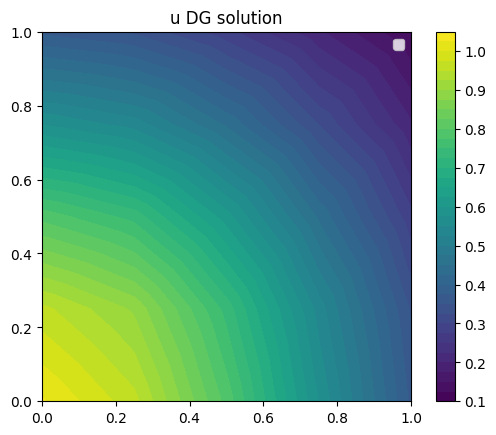



p = 2 
u : degree 1 , q : degree 1, sigma : degree 1
mesh = 4 x 4 x 2
|u-uh|_{L2} 	 |q-qh|_{L2} 	 |sigma-sigmah|_{L2}
0.0019809832658461 	  0.0929862755970392 	  0.0929862755970392




In [ ]:
# for p=2

# norm
def vecnorm(u):
  absu = pow(inner(u,u),0.5)
  return absu

def scalarnorm(u):
  absu = pow(pow(u,2),0.5)
  return absu


# DG discrete weak gradient operators
def Discrete_weak_gradient(v,g):
  (q,sigma,uu) = TrialFunctions(W)
  (zeta,tau,vv) = TestFunctions(W)
  # v = project(v,V3) # v function
  # g = project(g,V3) # g function

  # # choose C12
  C12 = Constant((1.0,0))
  dot_product = inner(C12,n('+'))
  sign = conditional(dot_product > 0, 1.0, -1.0)

  bc = DirichletBC(W.sub(2), g, "on_boundary")

  L = inner(q,zeta)*dx
  # R = -v*div(zeta)*dx + avg(v)*inner(jump(zeta),n('+'))*dS\
  #   + inner(C12,jump(v,n))*inner(jump(zeta),n('+'))*dS + g*inner(zeta,n)*ds
  R = -v*div(zeta)*dx + avg(v)*inner(jump(zeta),n('+'))*dS\
    + inner(0.5*sign,jump(v))*inner(jump(zeta),n('+'))*dS + g*inner(zeta,n)*ds

  F = L - R
  L = lhs(F)
  R = rhs(F)

  w = Function(W)
  solve(L==R,w,bc)
  (q,sigma,u) = w.split()

  return q

# energy functional
def J(u,g,eta):
  eta = Constant(eta)
  Dwg_u_g = Discrete_weak_gradient(u,g)
  Ju =  1/p*pow(vecnorm(Dwg_u_g),p)*dx\
     + 1/p*eta*pow(h_avg,1-p)*pow(vecnorm(jump(u,n)),p)*dS\
     + 1/p*eta*pow(h,1-p)*pow(scalarnorm(u-g),p)*ds - f*u*dx

  return Ju

# nonlinear coefficient
def nonlinear(vec):
  nonlinear = pow((vecnorm(vec)),p-2)*vec
  return nonlinear


# calculate derivative of energy functional
def dJudv_value(u,g,v,eta,Dwg1,Dwg2): # v function
  eta = Constant(eta)
  nonlinear1 = nonlinear(Dwg1)
  nonlinear2 = nonlinear((1/h_avg)*jump(u,n))
  nonlinear3 = nonlinear((1/h)*(u-g)*n)

  dJudv_value = inner(nonlinear1,Dwg2)*dx\
            + eta*inner(nonlinear2,jump(v,n))*dS\
            + eta*inner(nonlinear3,v*n)*ds - f*v*dx

  return assemble(dJudv_value)


# derivative of energy functional
def dJudv_fn(u,g,v,eta): # v testfunction
  eta = Constant(eta)
  nonlinear2 = nonlinear((1/h_avg)*jump(u,n))
  nonlinear3 = nonlinear((1/h)*(u-g)*n)

  dJudv_fn =  eta*inner(nonlinear2,jump(v,n))*dS\
            + eta*inner(nonlinear3,v*n)*ds - f*v*dx

  return dJudv_fn


# ---- initial guess----
eta = 10.0
uD = Constant(0.0) # Dirichlet boundary
uex = project(uex,V3)
uD = uex
Juex_value = assemble(J(uex,uD,eta))

# initial guess

u0 = uex
# u0 = project(Expression("1-r ", degree=5,r=r), V3)
u0 = project(Expression("(x[0]-1)*x[0]*(x[1]-1)*x[1]", degree=5), V3)

# set Amat, bvec, Dwg_v_0, degree of freedoms

Amat = np.zeros((V3.dim(), V3.dim()))
bvec = np.zeros(V3.dim())
dofmap = V3.dofmap()
global_dofs = dofmap.dofs()

Dwg_phi_j_0_list = []
for j in range(V3.dim()):
    phi_j = Function(V3)
    phi_j.vector()[j] = 1
    # print("phi_j=",phi_j.vector().get_local())
    Dwg_phi_j_0_list.append(Discrete_weak_gradient(phi_j, Constant(0.0)))

print("Dimension V3: ",V3.dim())

# set boundary condition and collect boundary dofs

uD = project(uD,V3)
bc = DirichletBC(V3, uD, "on_boundary")
boundary_dofs = list(bc.get_boundary_values().keys())

eps = 1.0
tol = 1.0e-6
iter = 0
maxiter = 10
epsi = 0.0001 # avoid degeneracy

while eps > tol and iter < maxiter:

  w = TrialFunction(V3)
  v = TestFunction(V3)
  alpha = 1.0

# Find the steepest direction
# The first term of LHS and RHS for p=2

  Dwg_u0_g = Discrete_weak_gradient(u0,uD)
  for i in range(V3.dim()):
    Dwg_phi_i_0 = Dwg_phi_j_0_list[i]
    phivalue = assemble(inner(Dwg_u0_g, Dwg_phi_i_0) * dx)
    bvec[global_dofs[i]] = phivalue


    for j in range(V3.dim()):
      Dwg_phi_j_0 = Dwg_phi_j_0_list[j]
      phi_ij_value = assemble(inner(Dwg_phi_i_0, Dwg_phi_j_0) * dx)
      Amat[global_dofs[i], global_dofs[j]] = phi_ij_value

  # print("Amat: ",Amat)
  # print("bvec: ",bvec)

# method 1. convert the other terms of LHS and RHS to numpy and add them, respectively.
# method 2. apply boundary to the other terms

  weighted = assemble(Constant(eta)*(1/h_avg)*inner(jump(w,n),jump(v,n))*dS\
            + Constant(eta)*(1/h)*w*v*ds)
  # bc.apply(weighted) # method 2
  weighted = as_backend_type(weighted).mat() # method 1
  weighted = weighted.getValues(range(0,weighted.getSize()[0]), range(0,weighted.getSize()[1])) # method 1
  Amat = Amat + weighted # method 1
  # print("Amat =",Amat)


  dJudv = assemble(dJudv_fn(u0,uD,v,eta))
  # bc.apply(dJudv) # method 2
  dJudv_vec = dJudv.get_local() # method 1
  bvec = bvec + dJudv_vec # method 1
  # print("bvec =", bvec)


  # for dof in boundary_dofs:
  #   Amat[dof] = 0
  #   # Amat[dof, dof] = 1 # method 1
  #   bvec[dof] = 0


# convert numpy matrix to dolfin.cpp.la.PETScMatrix
  AMat = PETSc.Mat().createAIJ(Amat.shape)
  AMat.setUp()
  AMat.setValues(range(0, Amat.shape[0]), range(0, Amat.shape[1]), Amat)
  AMat.assemble()
  AMat = PETScMatrix(AMat)

  # AMat = AMat + weighted # method 2 # add the first and the other terms of LHS


# convert numpy vector to dolfin.cpp.la.PETScVector
  bVec = PETSc.Vec().createSeq(V3.dim())
  bVec.setValues(range(0,V3.dim()), bvec)
  bVec = PETScVector(bVec)

  # bVec = bVec + dJudv # method 2 # add the first and the other terms of RHS

  w = Function(V3)
  solve(AMat, w.vector(), -bVec)

  # print("w=",w.vector().get_local()[:])
# doing Backtrack line search

  tol_l = 1e-4
  c2 = 1e-4
  c1 = 0.6
  stepsize = alpha
  starting = u0
  direction = w

  Jw_value = assemble(J(w,uD,eta))
  Jz0_value = assemble(J(u0,uD,eta))
  Dwg_u0_g = Discrete_weak_gradient(direction,uD)
  Dwg_dire_0 = Discrete_weak_gradient(direction,Constant(0.0))
  dJudz0 = dJudv_value(starting,uD,direction,eta,Dwg_u0_g,Dwg_dire_0)

  zn = Function(V3)
  iter_l = 0

  while stepsize>tol_l:
    print("****line search iter=%d: stepsize=%.16f ****"%(iter_l,stepsize))
    iter_l  = iter_l + 1
    zn = starting+stepsize*direction
    Jzn_value = assemble(J(zn,uD,eta))
    if Jzn_value < Jz0_value+c2*stepsize*dJudz0:
      break
    else:
      stepsize = c1*stepsize

  print("After doing line search: ")
  print("iter_stepsize=%d:" %iter_l)
  print ("stepsize=%.16f Jz0=%.16f Jw=%.16f Jzn=%.16f Juex=%.16f" %(stepsize, Jz0_value, Jw_value, Jzn_value, Juex_value))

  alpha = stepsize
  u = u0 + alpha * w

  u_er = project(w, V3)
  u_exer = project(u-uex, V3)
  u_L2iter = sqrt(assemble(inner(u_er,u_er)*dx))
  uex_L2iter = sqrt(assemble(inner(u_exer,u_exer)*dx))
  eps = u_L2iter
  eps_ex =  uex_L2iter
  print ("iter=%d: error_iter=%.16f error_ex=%.16f" %(iter, eps, eps_ex))
  print (" ")

  u0 = u
  iter = iter + 1


# error computation

plt.figure()
c = plot(u)
plt.colorbar(c)
plt.title('u DG solution')
plt.legend()
plt.show()

q = project(grad(u), V1)
sigma = pow(sqrt(inner(grad(u), grad(u))),p-2)*grad(u)
sigma = project(sigma, V2)
u = project(u, V3)

V1 = FunctionSpace(mesh, P1); V2 = FunctionSpace(mesh, P2); V3 = FunctionSpace(mesh, P3)
qer = project(q-qex, V1)
sigmaer = project(sigma-sigmaex, V2)
uer = project(u-uex, V3)

q_L2er = sqrt( assemble(inner(qer,qer)*dx) )
sigma_L2er = sqrt( assemble(inner(sigmaer,sigmaer)*dx) )
u_L2er = sqrt( assemble(uer*uer*dx) )

print ("\n")
print("p = %d " %p)
print("u : degree %d , q : degree %d, sigma : degree %d" %(pdeg,pdeg,pdeg))
print("mesh = %d x %d x 2" %(size,size))
print ("|u-uh|_{L2} \t |q-qh|_{L2} \t |sigma-sigmah|_{L2}")
print ("%.16f \t  %.16f \t  %.16f" % (u_L2er, q_L2er, sigma_L2er))
print ("\n")

um = Function(V3)
um = u

In [ ]:
# for p=4
p = 4


import sys
start_time = time.time()



# norm
def vecnorm(u):
  absu = pow(inner(u,u),0.5)
  return absu

def scalarnorm(u):
  absu = pow(pow(u,2),0.5)
  return absu


# DG discrete weak gradient operators
def Discrete_weak_gradient(v,g):
  (q,sigma,uu) = TrialFunctions(W)
  (zeta,tau,vv) = TestFunctions(W)
  v = project(v,V3)
  g = project(g,V3)

  C12 = Constant((1.0,0))
  dot_product = inner(C12,n('+'))
  sign = conditional(dot_product > 0, 1.0, -1.0)

  bc = DirichletBC(W.sub(2), g, "on_boundary")

  L = inner(q,zeta)*dx

  R = -v*div(zeta)*dx + avg(v)*inner(jump(zeta),n('+'))*dS\
    + inner(0.5*sign,jump(v))*inner(jump(zeta),n('+'))*dS + g*inner(zeta,n)*ds

  F = L - R
  L = lhs(F)
  R = rhs(F)

  w = Function(W)
  solve(L==R,w,bc)
  (q,sigma,u) = w.split()

  return q

# energy functional
def J(u,g,eta):
  eta = Constant(eta)
  Dwg_u_g = Discrete_weak_gradient(u,g)
  Ju =  1/p*pow(vecnorm(Dwg_u_g),p)*dx\
     + 1/p*eta*pow(h_avg,1-p)*pow(vecnorm(jump(u,n)),p)*dS\
     + 1/p*eta*pow(h,1-p)*pow(scalarnorm(u-g),p)*ds - f*u*dx

  return Ju

# nonlinear coefficient
def nonlinear(vec):
  nonlinear = pow((vecnorm(vec)),p-2)*vec
  return nonlinear


# calculate derivative of energy functional
def dJudv_value(u,g,v,eta,Dwg1,Dwg2): # v function
  eta = Constant(eta)
  nonlinear1 = nonlinear(Dwg1)
  nonlinear2 = nonlinear((1/h_avg)*jump(u,n))
  nonlinear3 = nonlinear((1/h)*(u-g)*n)

  dJudv_value = inner(nonlinear1,Dwg2)*dx\
            + eta*inner(nonlinear2,jump(v,n))*dS\
            + eta*inner(nonlinear3,v*n)*ds - f*v*dx

  return assemble(dJudv_value)


# derivative of energy functional
def dJudv_fn(u,g,v,eta): # v testfunction
  eta = Constant(eta)
  nonlinear2 = nonlinear((1/h_avg)*jump(u,n))
  nonlinear3 = nonlinear((1/h)*(u-g)*n)

  dJudv_fn =  eta*inner(nonlinear2,jump(v,n))*dS\
            + eta*inner(nonlinear3,v*n)*ds - f*v*dx

  return dJudv_fn



eta = 10.0
uex = project(uex,V3)
uD = uex # Dirichlet boundary
Juex_value = assemble(J(uex,uD,eta))

# initial guess
u0 = um
# u0 = uex
# u0 = project(Expression("1-r ", degree=5,r=r), V3)
# u0 = project(Expression("(x[0]-1)*x[0]*(x[1]-1)*x[1]", degree=5), V3)

# set Amat, bvec, Dwg_v_0, degree of freedoms
Amat = np.zeros((V3.dim(), V3.dim()))
bvec = np.zeros(V3.dim())
dofmap = V3.dofmap()
global_dofs = dofmap.dofs()
Dwg_phi_j_0_list = []
for j in range(V3.dim()):
    phi_j = Function(V3)
    phi_j.vector()[j] = 1
    Dwg_phi_j_0_list.append(Discrete_weak_gradient(phi_j, Constant(0.0)))

print("Dimension V3: ",V3.dim())

# set boundary condition and collect boundary dofs
uD = project(uD,V3)
bc = DirichletBC(V3, uD , "on_boundary")
boundary_dofs = list(set(bc.get_boundary_values().keys()))


eps = 1.0
tol = 1.0e-6
iter = 0
maxiter = 40
epsi = 1.0e-14 # avoid degeneracy

while eps > tol and iter < maxiter:

  w = TrialFunction(V3)
  v = TestFunction(V3)
  alpha = 1.0

# Find the steepest direction
# The first term of LHS and RHS for p=4

  Dwg_u0_g = Discrete_weak_gradient(u0,uD)
  Dwg_u0_g_coe = nonlinear(Dwg_u0_g)
  Dwg_u0_g_norm = pow(vecnorm(Dwg_u0_g),p-2)

  for i in range(V3.dim()):
    Dwg_phi_i_0 = Dwg_phi_j_0_list[i]
    phivalue = assemble(inner(Dwg_u0_g_coe, Dwg_phi_i_0) * dx)
    bvec[global_dofs[i]] = phivalue
    # if np.isnan(phivalue)==False:
    #    sys.exit()

    for j in range(V3.dim()):
      Dwg_phi_j_0 = Dwg_phi_j_0_list[j]
      phi_ij_value = assemble((epsi + Dwg_u0_g_norm) * inner(Dwg_phi_i_0, Dwg_phi_j_0) * dx)
      Amat[global_dofs[i], global_dofs[j]] = phi_ij_value


  weighted = assemble(Constant(eta)*(1/h_avg) * (epsi +  pow(vecnorm((1/h_avg)*jump(u0,n)),p-2) ) *inner(jump(w,n),jump(v,n))*dS\
            + Constant(eta)*(1/h)* (epsi + pow(vecnorm((1/h)*(u0-uD)),p-2) ) * w * v * ds)
  Apetsc = as_backend_type(weighted).mat()
  Apetsc = Apetsc.getValues(range(0, Apetsc.getSize()[0]), range(0,  Apetsc.getSize()[1]))
  Amat = Amat + Apetsc
  # bc.apply(weighted)

  dJudv = assemble(dJudv_fn(u0,uD,v,eta))
  dJudv_vec = dJudv.get_local()
  bvec = bvec + dJudv_vec
  # bc.apply(dJudv)



# convert numpy matrix to dolfin.cpp.la.PETScMatrix
  AMat = PETSc.Mat().createAIJ(Amat.shape)
  AMat.setUp()
  AMat.setValues(range(0, Amat.shape[0]), range(0, Amat.shape[1]), Amat)
  AMat.assemble()
  AMat = PETScMatrix(AMat)

  # AMat = AMat + weighted  # add the first and the other terms of LHS


# convert numpy vector to dolfin.cpp.la.PETScVector
  bVec = PETSc.Vec().createSeq(V3.dim())
  bVec.setValues(range(0,V3.dim()), bvec)
  bVec = PETScVector(bVec)

  # bVec = bVec + dJudv # add the first and the other terms of RHS

  w = Function(V3)
  solve(AMat, w.vector(), -bVec)


# doing Backtrack line search

  tol_l = 1e-4
  c2 = 1e-4
  c1 = 0.6
  stepsize = alpha
  starting = u0
  direction = w

  Jw_value = assemble(J(w,uD,eta))
  Jz0_value = assemble(J(u0,uD,eta))
  Dwg_u0_g = Discrete_weak_gradient(direction,uD)
  Dwg_dire_0 = Discrete_weak_gradient(direction,Constant(0.0))
  dJudz0 = dJudv_value(starting,uD,direction,eta,Dwg_u0_g,Dwg_dire_0)

  zn = Function(V3)
  iter_l = 0

  while stepsize>tol_l:
    print("iter = ",iter)
    print("****line search iter=%d: stepsize=%.16f ****"%(iter_l,stepsize))
    iter_l  = iter_l + 1
    zn = starting+stepsize*direction
    Jzn_value = assemble(J(zn,uD,eta))
    if Jzn_value < Jz0_value+c2*stepsize*dJudz0:
      break
    else:
      stepsize = c1*stepsize

  print("After doing line search: ")
  print("iter_stepsize=%d:" %iter_l)
  print ("stepsize=%.16f Jz0=%.16f Jw=%.16f Jzn=%.16f Juex=%.16f" %(stepsize, Jz0_value, Jw_value, Jzn_value, Juex_value))

  alpha = stepsize
  u = u0 + alpha * w

  u_er = project(w, V3)
  u_exer = project(u-uex, V3)
  u_L2iter = sqrt(assemble(inner(u_er,u_er)*dx))
  uex_L2iter = sqrt(assemble(inner(u_exer,u_exer)*dx))
  eps = u_L2iter
  eps_ex =  uex_L2iter
  print ("iter=%d: error_iter=%.16f error_ex=%.16f" %(iter, eps, eps_ex))
  print (" ")

  u0 = u
  iter = iter + 1


# error computation

# plt.figure()
# c = plot(u)
# plt.colorbar(c)
# plt.title('u DG solution')
# plt.legend()
# plt.show()

q = project(grad(u), V1)
sigma = pow(sqrt(inner(grad(u), grad(u))),p-2)*grad(u)
sigma = project(sigma, V2)
u = project(u, V3)

V1 = FunctionSpace(mesh, P1); V2 = FunctionSpace(mesh, P2); V3 = FunctionSpace(mesh, P3)
qer = project(q-qex, V1)
sigmaer = project(sigma-sigmaex, V2)
uer = project(u-uex, V3)

#L2
q_L2er = sqrt( assemble(inner(qer,qer)*dx) )
sigma_L2er = sqrt( assemble(inner(sigmaer,sigmaer)*dx) )
u_L2er = sqrt( assemble(uer*uer*dx) )

#Lp
q_Lper = pow(assemble(pow(vecnorm(qer),p)*dx),1.0/p)
sigma_Lper = pow(assemble(pow(vecnorm(sigmaer),p)*dx),1.0/p)
u_Lper = pow(assemble(pow(uer,p)*dx),1.0/p)

print ("\n")
print("p = %d " %p)
print("u : degree %d , q : degree %d, sigma : degree %d" %(pdeg,pdeg,pdeg))
print("mesh = %d x %d x 2" %(size,size))
print ("|u-uh|_{L2} \t |q-qh|_{L2} \t |sigma-sigmah|_{L2}")
print ("%.16f \t  %.16f \t  %.16f" % (u_L2er, q_L2er, sigma_L2er))
print ("|u-uh|_{Lp} \t |q-qh|_{Lp} \t |sigma-sigmah|_{Lp}")
print ("%.16f \t  %.16f \t  %.16f" % (u_Lper, q_Lper, sigma_Lper))
end_time = time.time()
execution_time = (end_time - start_time)/60.0
print("Execution time：", execution_time, "min")
print ("\n")




# dofmap = V.dofmap()
# # dd = Expression("x[0]", degree=5)
# dd = Function(V)
# dd.vector()[0] = 1
# # print("dd=",dd.vector().get_local())
# dof_coords = V.tabulate_dof_coordinates()
# # print("dof_coords=",dof_coords)


Test

In [ ]:
from fenics import *
from dolfin import *
from petsc4py import PETSc
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt


pdeg = 3
size = 4

mesh = UnitSquareMesh(size, size)
V = FunctionSpace(mesh, "DG", pdeg)
u = TrialFunction(V)
v = TestFunction(V)
alpha = Constant(10.0)
n = FacetNormal(mesh)
h = CellDiameter(mesh)
h_avg = (h('+') + h('-'))/2


f = Expression("2*pow(pi, 2)*sin(pi*x[0])*sin(pi*x[1])", degree=5, pi=np.pi)
uex = Expression("sin(pi*x[0])*sin(pi*x[1])", degree=5, pi=np.pi)

f = Expression("4*(-pow(x[0],2)-pow(x[1],2)+1)*exp(-1*pow(x[0],2.0)-1*pow(x[1],2.0))",degree=5)
uex = Expression("exp(-1*pow(x[0],2.0)-1*pow(x[1],2.0))",degree=5)
uD = project(uex, V)



bc = DirichletBC(V, uD ,"on_boundary")

Amat = np.zeros((V.dim(), V.dim()))
bvec = np.zeros(V.dim())
dofmap = V.dofmap()
global_dofs = dofmap.dofs()


# The first term of a and L
# dot( grad (u), grad (v) )*dx , f*v*dx
for i in range(V.dim()):
    phi_i = Function(V)
    phi_i.vector()[i] = 1
    phivalue = assemble(f * phi_i * dx)
    bvec[global_dofs[i]] = phivalue

    for j in range(V.dim()):
        phi_j = Function(V)
        phi_j.vector()[j] = 1
        phi_ij = assemble(inner(grad(phi_i), grad(phi_j)) * dx)
        Amat[global_dofs[i], global_dofs[j]] = phi_ij

# print("A:",Amat)
# print("b:",bvec)


a = assemble(-dot(avg(grad(u)),jump(v,n))*dS-dot(avg(grad(v)),jump(u,n))*dS\
    +alpha / h_avg *dot( jump (v, n), jump (u, n))*dS\
    -dot(grad(u),v*n)*ds-dot(grad(v),u*n)*ds\
    +alpha /h*u*v*ds )

L = assemble(-dot(grad(v),uD*n)*ds\
    +alpha /h*uD*v*ds )


Apetsc = as_backend_type(a).mat()
Apetsc = Apetsc.getValues(range(0, Apetsc.getSize()[0]), range(0,  Apetsc.getSize()[1]))
Amat = Amat + Apetsc

L_vec = L.get_local()
bvec = bvec + L_vec


# convert numpy matrix to dolfin.cpp.la.PETScMatrix
AMat = PETSc.Mat().createAIJ(Amat.shape)
# print(type(AMat))
AMat.setUp()
AMat.setValues(range(0, Amat.shape[0]), range(0, Amat.shape[1]), Amat)
AMat.assemble()
AMat = PETScMatrix(AMat)

# convert numpy vector to dolfin.cpp.la.PETScVector
bVec = PETSc.Vec().createSeq(V.dim())
bVec.setValues(range(0,V.dim()), bvec)
bVec = PETScVector(bVec)

sol = Function(V)
solve(AMat, sol.vector(), bVec)

uer = project(uex-sol,V)
u_L2er = sqrt( assemble(uer*uer*dx) )

print("use inner(grad(phi),grad(phj)),  u_L2 error:",u_L2er)

# plt.figure()
# c = plot(sol)
# plt.colorbar(c)
# plt.title('u DG solution')
# plt.legend()
# plt.show()

<class 'petsc4py.PETSc.Mat'>
use inner(grad(phi),grad(phj)),  u_L2 error: 2.8329330725252417e-05


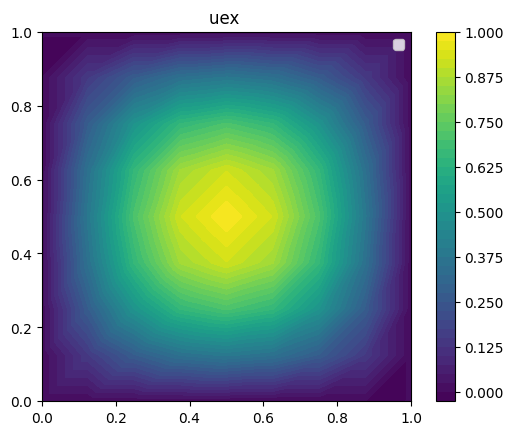

Dimension V3:  1280
****line search iter=0: stepsize=1.0000000000000000 ****
After doing line search: 
iter_stepsize=1:
stepsize=1.0000000000000000 Jz0=-2.4673522638699334 Jw=0.0000494140855923 Jzn=-2.4673536301537715 Juex=-2.4673522638699339
iter=0: error_iter=0.0000148195780400 error_ex=0.0000148195780400
 
****line search iter=0: stepsize=1.0000000000000000 ****
After doing line search: 
iter_stepsize=1:
stepsize=1.0000000000000000 Jz0=-2.4673536301537715 Jw=0.0000002862826064 Jzn=-2.4673536301537724 Juex=-2.4673522638699339
iter=1: error_iter=0.0000000000000002 error_ex=0.0000148195780400
 
 
ubdcon =  0.0002704127190605373
grad_Lper =  0.0012498679439219174
Juer =  0.00015613900843414186
 


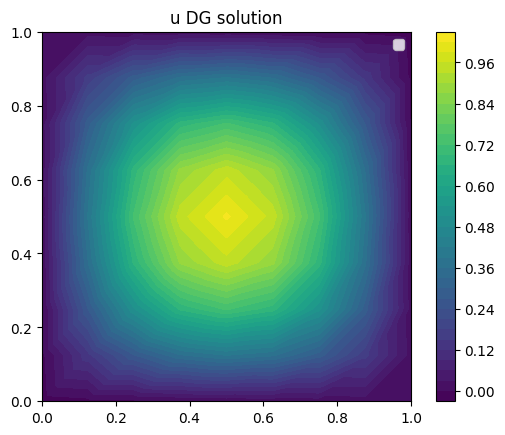



p = 2 
u : degree 3 , q : degree 3, sigma : degree 3
mesh = 8 x 8 x 2
|u-uh|_{L2} 	 |q-qh|_{L2} 	 |sigma-sigmah|_{L2}
0.0000148195780400 	  0.0015978525328552 	  0.0015978525328552




In [ ]:
from fenics import *
from dolfin import *
from dolfin import set_log_level, LogLevel
from petsc4py import PETSc
from scipy.sparse import csr_matrix
from mshr import *
import numpy as np
import sympy as sp
from sympy import pi , sin ,cos
import matplotlib.pyplot as plt
import math
import time


x, y = sp.symbols('x[0] x[1]')
p = 2 # p-Laplace
test = 2 # test problem
pdeg = 3
size = 8


# Exact sol / source term f

if p==2:
  if test==1:
    tol = 0.1
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    f = 4*(-x**2 - y**2 + 1)*sp.exp(-x**2 - y**2)
    f = Expression(sp.printing.ccode(f), degree=3)
    uex = Expression("exp(-1*pow(x[0],2.0)-1*pow(x[1],2.0))",degree=3)
    qex = Expression(("-2*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " -2*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3)
    sigmaex = Expression(("-2*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " -2*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3)
    Coe = Constant(1.0)
  elif test==2:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    f = Expression(" 2*pow(pi,2)*sin(pi*x[0])*sin(pi*x[1])", degree=5,pi=math.pi)
    uex = Expression(" sin(pi*x[0])*sin(pi*x[1])",degree=5,pi=math.pi)
    qex = Expression((" pi*sin(pi*x[1])*cos(pi*x[0]) "," pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi)
    sigmaex = Expression((" pi*sin(pi*x[1])*cos(pi*x[0]) "," pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi)
    Coe = Constant(1.0)
  elif test==3:
    # domain = Circle(Point(0, 0), 1, 50)
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=3)
    uex = Expression("(1.0/4)*(1-pow(r,2.0))", degree=3,r=r)
    qex = Expression(("-0.5*x[0] " , "-0.5*x[1]"),degree=3)
    Coe = Constant(1.0)
    sigmaex = Expression(("Coe*-0.5*x[0] " , "Coe*-0.5*x[1]"),degree=3,Coe=Coe)
    f = Constant(1.0)
  elif test==5:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=5)
    uex = Expression("r<0.3 ? 0 : pow((r-0.3),4) ", degree=5, r=r)
    qex1 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[0]/r ", degree=5, r=r)
    qex2 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[1]/r ", degree=5, r=r)
    qex = as_vector((qex1,qex2))
    sigmaex1 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[0]/r ", degree=5, r=r)
    sigmaex2 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[1]/r ", degree=5, r=r)
    sigmaex = as_vector((sigmaex1,sigmaex2))
    f = Expression("r<0.3 ? 0 : 4*pow((r-0.3),2)*(0.3/r - 4) ", degree=5, r=r)



else:
  if test==1:
    tol = 0.1
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    f =  2*(8.0*((x**2 + y**2)*sp.exp(-2*x**2 - 2*y**2))**1.0*(-x**2 - y**2 + 1)*sp.exp(3*x**2 + 3*y**2) - (x**2 + y**2)*(16.0*x**2 + 16.0*y**2 - 8.0)*sp.exp(x**2 + y**2))*sp.exp(-4*x**2 - 4*y**2)
    f = Expression(sp.printing.ccode(f), degree=3)
    uex = Expression("exp(-1*pow(x[0],2)-1*pow(x[1],2))",degree=3)
    qex = Expression(("-2*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " -2*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3)
    Coe = ((4*x**2*sp.exp(-2*x**2 - 2*y**2) + 4*y**2*sp.exp(-2*x**2 - 2*y**2))**0.5 )**2.0
    Coe = Expression(sp.printing.ccode(Coe), degree=3)
    sigmaex = Expression(("Coe*(-2)*x[0]*exp(-1*pow(x[0],2)-1*pow(x[1],2)) " , " Coe*(-2)*x[1]*exp(-1*pow(x[0],2)-1*pow(x[1],2))"),degree=3,Coe = Coe)
  elif test==2:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    uex = Expression(" sin(pi*x[0])*sin(pi*x[1])",degree=5,pi=math.pi)
    qex = Expression((" pi*sin(pi*x[1])*cos(pi*x[0]) "," pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi)
    Coe = Expression("pow((pow(pi,2)*pow(sin(pi*x[0]),2)*pow(cos(pi*x[1]),2) + pow(pi,2)*pow(sin(pi*x[1]),2)*pow(cos(pi*x[0]),2)),1.0)", degree=5,pi=math.pi)
    sigmaex = Expression((" Coe*pi*sin(pi*x[1])*cos(pi*x[0]) "," Coe*pi*sin(pi*x[0])*cos(pi*x[1]) "),degree=5,pi=math.pi,Coe=Coe)
    f = Expression(" (0.5*pow(pi,4.0)*(-cos(pi*(2*x[0] - 2*x[1])) - cos(pi*(2*x[0] + 2*x[1])) + 2) - 2.0*pow(pi,4)*pow(cos(pi*x[0]),2)*cos(2*pi*x[1]) - 2.0*pow(pi,4)*cos(2*pi*x[0])*pow(cos(pi*x[1]),2))*sin(pi*x[0])*sin(pi*x[1])", degree=5,pi=math.pi)
  elif test==3:
    domain = Circle(Point(0, 0), 1, 50)
    mesh = generate_mesh(domain, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=3)
    uex = Expression("(3.0/4)*pow(1.0/2,1.0/3)*(1-pow(r,4.0/3))", degree=3,r=r)
    qex = Expression(("-0.7937005259841*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333) " , " -0.7937005259841*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333)"),degree=3)
    Coe = Expression("0.629960524947437*pow((pow(x[0],2)/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) + pow(x[1],2)/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)),1.0)", degree=3,r=r)
    sigmaex = Expression(("Coe*-0.707106781186547*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.25) " , " Coe*-0.707106781186547*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.25)"),degree=3,Coe=Coe)
    f = 0.666666666666667/(x**2 + y**2)**4.44089209850063e-16 + 0.333333333333333
    f = Expression(sp.printing.ccode(f), degree=3)
  elif test==4:
    mesh = RectangleMesh(Point(1, 1), Point(2, 2), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=3)
    uex = Expression("pow(r,(p-2)/(p-1))",degree=3,r=r,p=p)
    qex = Expression(("0.666666666666667*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) " , " 0.666666666666667*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)"),degree=3)
    Coe = 0.444444444444444*(x**2/(x**2 + y**2)**1.33333333333333 + y**2/(x**2 + y**2)**1.33333333333333)**1.0
    Coe = Expression(sp.printing.ccode(Coe), degree=3)
    sigmaex = Expression(("Coe*0.666666666666667*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) " , "Coe* 0.666666666666667*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)"),degree=3,Coe=Coe)
    f = 1.66533453693773e-16/(x**2 + y**2)**1.0
    f = Expression(sp.printing.ccode(f), degree=3)
  elif test==5:
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=5)
    uex = Expression("r<0.3 ? 0 : pow((r-0.3),4) ", degree=5, r=r)
    qex1 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[0]/r ", degree=5, r=r)
    qex2 = Expression("r<0.3 ? 0 : 4*pow((r-0.3),3)*x[1]/r ", degree=5, r=r)
    qex = as_vector((qex1,qex2))
    sigmaex1 = Expression("r<0.3 ? 0 : 64*pow((r-0.3),9)*x[0]/r ", degree=5, r=r)
    sigmaex2 = Expression("r<0.3 ? 0 : 64*pow((r-0.3),9)*x[1]/r ", degree=5, r=r)
    sigmaex = as_vector((sigmaex1,sigmaex2))
    f = Expression("r<0.3 ? 0 : 64*pow((r-0.3),8)*(0.3/r - 10) ", degree=5, r=r)
  elif test==6:
    mesh = RectangleMesh(Point(0.1, 0.1), Point(1, 1), size, size)
    # r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=5)
    r = (x**2+y**2)**0.5
    R = 1.5
    uex = 1-(3.0/2)*((r/R)**(4.0/3)-(1-r/R)**(4.0/3)+1-(4.0/3)*(r/R))
    uex = Expression(sp.printing.ccode(uex), degree=5)
    qex1 = Expression("-1.33333333333333*x[0]*pow((1 - 0.666666666666667*pow((pow(x[0],2) + pow(x[1],2)),0.5)),0.333333333333333)/pow((pow(x[0],2) + pow(x[1],2)),0.5) + 1.33333333333333*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.5) - 1.16477395298173*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333)",degree=5)
    qex2 = Expression("-1.33333333333333*x[1]*pow((1 - 0.666666666666667*pow((pow(x[0],2) + pow(x[1],2)),0.5)),0.333333333333333)/pow((pow(x[0],2) + pow(x[1],2)),0.5) + 1.33333333333333*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.5) - 1.16477395298173*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.333333333333333)",degree=5)
    qex = Expression(("qex1"," qex2"),qex1=qex1, qex2=qex2 ,degree=5)
    Coe =  1.77777777777778*((-x*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333/(x**2 + y**2)**0.5 + x/(x**2 + y**2)**0.5 - 0.873580464736299*x/(x**2 + y**2)**0.333333333333333)**2 + (-y*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333/(x**2 + y**2)**0.5 + y/(x**2 + y**2)**0.5 - 0.873580464736299*y/(x**2 + y**2)**0.333333333333333)**2)**1.0
    Coe = Expression(sp.printing.ccode(Coe), degree=5)
    sigmaex = Expression(("Coe*qex1" , "Coe*qex2"),degree=5,Coe=Coe,qex1=qex1, qex2=qex2)
    f =  ((((x**2 + y**2)**0.333333333333333*((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 1) + 0.873580464736299*(x**2 + y**2)**0.5)**2/(x**2 + y**2)**0.666666666666667)**1.0*(x**2 + y**2)**11.0*(x**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.37037037037037 - 2.37037037037037*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**3.16666666666667 - 1.38047283316353*x**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**3.33333333333333 - 0.526748971193415*x**2*(x**2 + y**2)**3.66666666666667 + y**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.37037037037037 - 2.37037037037037*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**3.16666666666667 - 1.38047283316353*y**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**3.33333333333333 - 0.526748971193415*y**2*(x**2 + y**2)**3.66666666666667 + (1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.16666666666667*(4.74074074074074*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 4.74074074074074) + 4.1414184994906*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.33333333333333) + 1.77777777777778*(x**2 + y**2)**4.66666666666667*(x**2*(y**2*(x**2 + y**2)**5.5*((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.0 - 2.0*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**2.33333333333333 - 1.16477395298173*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**2.5 - 0.444444444444444*(x**2 + y**2)**2.83333333333333) + (x**2 + y**2)**4.66666666666667*(x**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.0 - 2.0*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**3.16666666666667 - 1.16477395298173*x**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**3.33333333333333 - 0.444444444444444*x**2*(x**2 + y**2)**3.66666666666667 + (1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.16666666666667*(2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 2) + 1.7471609294726*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.33333333333333)) + y**2*(x**2*(x**2 + y**2)**5.5*((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.0 - 2.0*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**2.33333333333333 - 1.16477395298173*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**2.5 - 0.444444444444444*(x**2 + y**2)**2.83333333333333) + (x**2 + y**2)**4.66666666666667*(y**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(2.0 - 2.0*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333)*(x**2 + y**2)**3.16666666666667 - 1.16477395298173*y**2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**3.33333333333333 - 0.444444444444444*y**2*(x**2 + y**2)**3.66666666666667 + (1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.16666666666667*(2*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 2) + 1.7471609294726*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**4.33333333333333)))*((x**2 + y**2)**0.333333333333333*((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 1) + 0.873580464736299*(x**2 + y**2)**0.5)*((x**2 + y**2)**0.333333333333333*(1.33333333333333*(1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.333333333333333 - 1.33333333333333) + 1.16477395298173*(x**2 + y**2)**0.5))/((1 - 0.666666666666667*(x**2 + y**2)**0.5)**0.666666666666667*(x**2 + y**2)**15.6666666666667)
    f = Expression(sp.printing.ccode(f), degree=5)
  else:
    mesh = RectangleMesh(Point(0.1, 0.1), Point(1, 1), size, size)
    r = Expression("pow((pow(x[0],2)+pow(x[1],2)),0.5)", degree=3)
    uex = Expression("sin(pi*x[0])*sin(pi*x[1]) ",degree=3,pi=math.pi)
    qex = Expression(("pi*sin(pi*x[1])*cos(pi*x[0]) " , " pi*sin(pi*x[0])*cos(pi*x[1])"),degree=3,pi=math.pi)
    Coe = ((0.1 * sp.pi * x * sp.sin(sp.pi * sp.sqrt(x**2 + y**2)) / sp.sqrt(x**2 + y**2) + sp.pi * sp.sin(sp.pi * y) * sp.cos(sp.pi * x))**2 + (0.1 * sp.pi * y * sp.sin(sp.pi * sp.sqrt(x**2 + y**2)) / sp.sqrt(x**2 + y**2) + sp.pi * sp.sin(sp.pi * x) * sp.cos(sp.pi * y))**2)**1.0
    Coe = Expression(sp.printing.ccode(Coe), degree=3)
    sigmaex = Expression(("Coe*0.666666666666667*x[0]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667) " , "Coe* 0.666666666666667*x[1]/pow((pow(x[0],2) + pow(x[1],2)),0.666666666666667)"),degree=3,Coe=Coe)
    f = (pi**3.0*(((0.1*x*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*y)*cos(pi*x))**2 + (0.1*y*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*x)*cos(pi*y))**2)/(x**2 + y**2)**1.0)**1.0*(x**2 + y**2)**7.0*(0.1*x**2*(x**2 + y**2)**1.5*sin(pi*(x**2 + y**2)**0.5) - 0.1*pi*x**2*(x**2 + y**2)**2.0*cos(pi*(x**2 + y**2)**0.5) + 0.1*y**2*(x**2 + y**2)**1.5*sin(pi*(x**2 + y**2)**0.5) - 0.1*pi*y**2*(x**2 + y**2)**2.0*cos(pi*(x**2 + y**2)**0.5) - 0.2*(x**2 + y**2)**2.5*sin(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**3.0*sin(pi*x)*sin(pi*y)) + 1.0*pi**3*(x**2 + y**2)**3.0*((0.1*x*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*y)*cos(pi*x))*((x**2 + y**2)**3.0*(0.1*x*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*y)*cos(pi*x))*(0.2*x**2*(x**2 + y**2)**1.5*sin(pi*(x**2 + y**2)**0.5) - 0.2*pi*x**2*(x**2 + y**2)**2.0*cos(pi*(x**2 + y**2)**0.5) - 0.2*(x**2 + y**2)**2.5*sin(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**3.0*sin(pi*x)*sin(pi*y)) - (x**2 + y**2)**3.5*(0.1*y*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*x)*cos(pi*y))*(-0.2*x*y*(x**2 + y**2)**1.0*sin(pi*(x**2 + y**2)**0.5) + 0.2*pi*x*y*(x**2 + y**2)**1.5*cos(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**2.5*cos(pi*x)*cos(pi*y))) - (0.1*y*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*x)*cos(pi*y))*(-(x**2 + y**2)**3.0*(0.1*y*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*x)*cos(pi*y))*(0.2*y**2*(x**2 + y**2)**1.5*sin(pi*(x**2 + y**2)**0.5) - 0.2*pi*y**2*(x**2 + y**2)**2.0*cos(pi*(x**2 + y**2)**0.5) - 0.2*(x**2 + y**2)**2.5*sin(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**3.0*sin(pi*x)*sin(pi*y)) + (x**2 + y**2)**3.5*(0.1*x*sin(pi*(x**2 + y**2)**0.5) + (x**2 + y**2)**0.5*sin(pi*y)*cos(pi*x))*(-0.2*x*y*(x**2 + y**2)**1.0*sin(pi*(x**2 + y**2)**0.5) + 0.2*pi*x*y*(x**2 + y**2)**1.5*cos(pi*(x**2 + y**2)**0.5) + 2.0*pi*(x**2 + y**2)**2.5*cos(pi*x)*cos(pi*y)))))/(x**2 + y**2)**10.0
    f = Expression(sp.printing.ccode(f), degree=3)
    b = -0.1*cos(pi*(x**2 + y**2)**0.5)
    b = Expression(sp.printing.ccode(b), degree=3)

P1 = VectorElement("DG", triangle, pdeg)
P2 = VectorElement("DG", triangle, pdeg)
P3 = FiniteElement("DG", triangle, pdeg)
P1P2P3 = MixedElement([P1, P2, P3])
W = FunctionSpace(mesh, P1P2P3)


V1 = FunctionSpace(mesh, P1)
V2 = FunctionSpace(mesh, P2)
V3 = FunctionSpace(mesh, P3)

(q,sigma,u) = TrialFunctions(W)
(zeta,tau,v) = TestFunctions(W)

n = FacetNormal(mesh)
h = CellDiameter(mesh)
h_avg = (h('+') + h('-'))/2


# norm
def vecnorm(u):
  absu = pow(inner(u,u),0.5)
  return absu

def scalarnorm(u):
  absu = pow(pow(u,2),0.5)
  return absu


# DG discrete weak gradient operators
def Discrete_weak_gradient(v,g):
  (q,sigma,uu) = TrialFunctions(W)
  (zeta,tau,vv) = TestFunctions(W)
  v = project(v,V3) # v function
  g = project(g,V3) # g function

  # # choose C12
  C12 = Constant((1.0,0))
  dot_product = inner(C12,n('+'))
  sign = conditional(dot_product > 0, 1.0, -1.0)
  # sign = conditional(dot_product > 0, 1.0,conditional(dot_product < 0, -1.0, 0.0) )

  bc = DirichletBC(W.sub(2), g, "on_boundary")

  L = inner(q,zeta)*dx

  R = -v*div(zeta)*dx + avg(v)*inner(jump(zeta),n('+'))*dS\
    + inner(0.5*sign,jump(v))*inner(jump(zeta),n('+'))*dS + g*inner(zeta,n)*ds

  F = L - R
  L = lhs(F)
  R = rhs(F)

  w = Function(W)
  solve(L==R,w,bc)
  (q,sigma,u) = w.split()

  return q

# continuous energy functional
def Jc(u):
  Ju =  1/p*pow(vecnorm(grad(u)),p)*dx - f*u*dx
  return Ju


# discrete energy functional

def J(u,g,eta):
  eta = Constant(eta)
  Dwg_u_g = Discrete_weak_gradient(u,g)
  Ju =  1/p*pow(vecnorm(Dwg_u_g),p)*dx\
     + 1/p*eta*pow(h_avg,1-p)*pow(vecnorm(jump(u,n)),p)*dS\
     + 1/p*eta*pow(h,1-p)*pow(scalarnorm(u-g),p)*ds - f*u*dx

  return Ju

# nonlinear coefficient
def nonlinear(vec):
  nonlinear = pow((vecnorm(vec)),p-2)*vec
  return nonlinear


# calculate derivative of energy functional
def dJudv_value(u,g,v,eta,Dwg1,Dwg2): # v function
  eta = Constant(eta)
  nonlinear1 = nonlinear(Dwg1)
  nonlinear2 = nonlinear((1/h_avg)*jump(u,n))
  nonlinear3 = nonlinear((1/h)*(u-g)*n)

  dJudv_value = inner(nonlinear1,Dwg2)*dx\
            + eta*inner(nonlinear2,jump(v,n))*dS\
            + eta*inner(nonlinear3,v*n)*ds - f*v*dx

  return assemble(dJudv_value)


# derivative of energy functional
def dJudv_fn(u,g,v,eta): # v testfunction
  eta = Constant(eta)
  nonlinear2 = nonlinear((1/h_avg)*jump(u,n))
  nonlinear3 = nonlinear((1/h)*(u-g)*n)

  dJudv_fn =  eta*inner(nonlinear2,jump(v,n))*dS\
            + eta*inner(nonlinear3,v*n)*ds - f*v*dx

  return dJudv_fn



eta = 10.0
uD = Constant(0.0) # Dirichlet boundary
uex = project(uex,V3)
uD = uex
Juex_value = assemble(J(uex,uD,eta))


plt.figure()
c3 = plot(uex)
plt.colorbar(c3)
plt.title('uex ')
plt.legend()
plt.show()

# initial guess

u0 = uex
# u0 = project(Expression("1-r ", degree=5,r=r), V3)
# u0 = project(Expression("(x[0]-1)*x[0]*(x[1]-1)*x[1]", degree=5), V3)

# set Amat, bvec, Dwg_v_0, degree of freedoms

Amat = np.zeros((V3.dim(), V3.dim()))
bvec = np.zeros(V3.dim())
dofmap = V3.dofmap()
global_dofs = dofmap.dofs()

Dwg_phi_j_0_list = []
for j in range(V3.dim()):
    phi_j = Function(V3)
    phi_j.vector()[j] = 1
    # print("phi_j=",phi_j.vector().get_local())
    Dwg_phi_j_0_list.append(Discrete_weak_gradient(phi_j, Constant(0.0)))

print("Dimension V3: ",V3.dim())

# set boundary condition and collect boundary dofs



uD = project(uD,V3)
bc = DirichletBC(V3, uD, "on_boundary")
boundary_dofs = list(bc.get_boundary_values().keys())

eps = 1.0
tol = 1.0e-6
iter = 0
maxiter = 10
# epsi = 0.0001 # avoid degeneracy

while eps > tol and iter < maxiter:

  w = TrialFunction(V3)
  v = TestFunction(V3)
  alpha = 1.0

# Find the steepest direction
# The first term of LHS and RHS for p=2

  Dwg_u0_g = Discrete_weak_gradient(u0,uD)
  for i in range(V3.dim()):
    Dwg_phi_i_0 = Dwg_phi_j_0_list[i]
    phivalue = assemble(inner(Dwg_u0_g, Dwg_phi_i_0) * dx)
    bvec[global_dofs[i]] = phivalue


    for j in range(V3.dim()):
      Dwg_phi_j_0 = Dwg_phi_j_0_list[j]
      phi_ij_value = assemble(inner(Dwg_phi_i_0, Dwg_phi_j_0) * dx)
      Amat[global_dofs[i], global_dofs[j]] = phi_ij_value

  # print("Amat: ",Amat)
  # print("bvec: ",bvec)

# method 1. convert the other terms of LHS and RHS to numpy and add them, respectively.
# method 2. apply boundary to the other terms

  weighted = assemble(Constant(eta)*(1/h_avg)*inner(jump(w,n),jump(v,n))*dS\
            + Constant(eta)*(1/h)*w*v*ds)
  # bc.apply(weighted) # method 2
  weighted = as_backend_type(weighted).mat() # method 1
  weighted = weighted.getValues(range(0,weighted.getSize()[0]), range(0,weighted.getSize()[1])) # method 1
  Amat = Amat + weighted # method 1
  # print("Amat =",Amat)


  dJudv = assemble(dJudv_fn(u0,uD,v,eta))
  # bc.apply(dJudv) # method 2
  dJudv_vec = dJudv.get_local() # method 1
  bvec = bvec + dJudv_vec # method 1
  # print("bvec =", bvec)


  # for dof in boundary_dofs:
  #   Amat[dof] = 0
  #   # Amat[dof, dof] = 1 # method 1
  #   bvec[dof] = 0


# convert numpy matrix to dolfin.cpp.la.PETScMatrix
  AMat = PETSc.Mat().createAIJ(Amat.shape)
  AMat.setUp()
  AMat.setValues(range(0, Amat.shape[0]), range(0, Amat.shape[1]), Amat)
  AMat.assemble()
  AMat = PETScMatrix(AMat)

  # AMat = AMat + weighted # method 2 # add the first and the other terms of LHS


# convert numpy vector to dolfin.cpp.la.PETScVector
  bVec = PETSc.Vec().createSeq(V3.dim())
  bVec.setValues(range(0,V3.dim()), bvec)
  bVec = PETScVector(bVec)

  # bVec = bVec + dJudv # method 2 # add the first and the other terms of RHS

  w = Function(V3)
  solve(AMat, w.vector(), -bVec)

  # print("w=",w.vector().get_local()[:])
# doing Backtrack line search

  tol_l = 1e-4
  c2 = 1e-4
  c1 = 0.6
  stepsize = alpha
  starting = u0
  direction = w

  Jw_value = assemble(J(w,uD,eta))
  Jz0_value = assemble(J(u0,uD,eta))
  Dwg_u0_g = Discrete_weak_gradient(u0,uD)
  Dwg_dire_0 = Discrete_weak_gradient(direction,Constant(0.0))
  dJudz0 = dJudv_value(starting,uD,direction,eta,Dwg_u0_g,Dwg_dire_0)

  zn = Function(V3)
  iter_l = 0

  while stepsize>tol_l:
    print("****line search iter=%d: stepsize=%.16f ****"%(iter_l,stepsize))
    iter_l  = iter_l + 1
    zn = starting+stepsize*direction
    Jzn_value = assemble(J(zn,uD,eta))
    if Jzn_value < Jz0_value+c2*stepsize*dJudz0:
      break
    else:
      stepsize = c1*stepsize

  print("After doing line search: ")
  print("iter_stepsize=%d:" %iter_l)
  print ("stepsize=%.16f Jz0=%.16f Jw=%.16f Jzn=%.16f Juex=%.16f" %(stepsize, Jz0_value, Jw_value, Jzn_value, Juex_value))

  alpha = stepsize
  u = u0 + alpha * w

  u_er = project(w, V3)
  u_exer = project(u-uex, V3)
  u_L2iter = sqrt(assemble(inner(u_er,u_er)*dx))
  uex_L2iter = sqrt(assemble(inner(u_exer,u_exer)*dx))
  eps = u_L2iter
  eps_ex =  uex_L2iter
  print ("iter=%d: error_iter=%.16f error_ex=%.16f" %(iter, eps, eps_ex))
  print (" ")

  u0 = u
  iter = iter + 1

# error computation


ubdcon = pow(assemble(pow(h_avg,1-p)*pow(vecnorm(jump(u-uex,n)),p)*dS\
     + pow(h,1-p)*pow(scalarnorm(u-uex),p)*ds),1.0/p)
print(" ")
print("ubdcon = ",ubdcon)

Dwg_u_g = Discrete_weak_gradient(u,uD)
gradu = grad(uex)
grader = project((Dwg_u_g - gradu),V1)
grad_L2er = sqrt( assemble(inner(grader,grader)*dx) )
print("grad_Lper = ",grad_L2er)

Juer = abs(assemble(J(u,uD,eta)) - assemble(Jc(uex)))
print("Juer = ",Juer)
print(" ")



plt.figure()
c = plot(u)
plt.colorbar(c)
plt.title('u DG solution')
plt.legend()
plt.show()

q = project(grad(u), V1)
sigma = pow(sqrt(inner(grad(u), grad(u))),p-2)*grad(u)
sigma = project(sigma, V2)
u = project(u, V3)

V1 = FunctionSpace(mesh, P1); V2 = FunctionSpace(mesh, P2); V3 = FunctionSpace(mesh, P3)
qer = project(q-qex, V1)
sigmaer = project(sigma-sigmaex, V2)
uer = project(u-uex, V3)

q_L2er = sqrt( assemble(inner(qer,qer)*dx) )
sigma_L2er = sqrt( assemble(inner(sigmaer,sigmaer)*dx) )
u_L2er = sqrt( assemble(uer*uer*dx) )



print ("\n")
print("p = %d " %p)
print("u : degree %d , q : degree %d, sigma : degree %d" %(pdeg,pdeg,pdeg))
print("mesh = %d x %d x 2" %(size,size))
print ("|u-uh|_{L2} \t |q-qh|_{L2} \t |sigma-sigmah|_{L2}")
print ("%.16f \t  %.16f \t  %.16f" % (u_L2er, q_L2er, sigma_L2er))
print ("\n")



In [ ]:

# def Backtrack_line_search(stepsize,starting,direction,c1,c2,tole):
#   iter=0
#   zn = Function(V1)
#   while stepsize>tole:
#     zn.vector()[:] = starting.vector()[:] + stepsize*direction.vector()[:]
#     Jz0 = assemble(1/p*pow(sqrt(inner(grad(starting), grad(starting))),p)*dx  - f*starting*dx)
#     Jzn =  assemble(1/p*pow(sqrt(inner(grad(zn), grad(zn))),p)*dx  - f*zn*dx)
#     if Jzn < Jz0+c2*stepsize*assemble(direction*dx):
#       break
#     else:
#       stepsize = c1*stepsize
#   return stepsize

# def Golden_Section_line_search(x1,x_guess,delta):
#   # x1 = Function(V1)
#   # x2 = Function(V1)
#   # x3 = Function(V1)
#   # x4 = Function(V1)
#   ratio = (sqrt(5.0) - 1)/2
#   x1 = x1
#   y1 = assemble(1/p*pow(sqrt(inner(grad(x1), grad(x1))),p)*dx  - f*x1*dx)
#   y4 = assemble(1/p*pow(sqrt(inner(grad(x_guess), grad(x_guess))),p)*dx  - f*x_guess*dx)
#   if y1<=y4:
#     x4 = x_guess
#     y4 = y4
#     x2 = (1-ratio)*x4 #.vector()[:]
#     y2 = assemble(1/p*pow(sqrt(inner(grad(x2), grad(x2))),p)*dx  - f*x2*dx)
#     while x4>delta:
#       if y1<=y2:
#         x4 = x2
#         y4 = y2
#         x2 = (1-ratio)*x4
#         y2 = assemble(1/p*pow(sqrt(inner(grad(x2), grad(x2))),p)*dx  - f*x2*dx)
#       else:
#         break
#   else:
#     x2 = x_guess
#     y2 = assemble(1/p*pow(sqrt(inner(grad(x2), grad(x2))),p)*dx  - f*x2*dx)
#     x4 = (1/ratio)*x2
#     y4 = assemble(1/p*pow(sqrt(inner(grad(x4), grad(x4))),p)*dx  - f*x4*dx)
#     while y2>y4:
#       x1 = x2
#       y1 = y2
#       x2 = x4
#       y2 = y4
#       x4 = (1/ratio)*x2
#       y4 = assemble(1/p*pow(sqrt(inner(grad(x4), grad(x4))),p)*dx  - f*x4*dx)

#   x3 = ratio*x2+(1-ratio)*x4
#   y3 = assemble(1/p*pow(sqrt(inner(grad(x3), grad(x3))),p)*dx  - f*x3*dx)

#   while x4-x1>delta:
#     if y2>y3:
#       x1 = x2
#       y1 = y2
#       x2 = x3
#       y2 = y3
#       x3 = ratio*x3+(1-ratio)*x4
#       y3 = assemble(1/p*pow(sqrt(inner(grad(x3), grad(x3))),p)*dx  - f*x3*dx)
#     else:
#       x4 = x3
#       y4 = y3
#       x3 = x2
#       y3 = y2
#       x2 = (1-ratio)*x1 + ratio*x2
#       y2 = assemble(1/p*pow(sqrt(inner(grad(x2), grad(x2))),p)*dx  - f*x2*dx)
#   ylist = [y1,y2,y3,y4]
#   yout = np.min(ylist)
#   i = np.argmin(ylist)
#   xlist = [x1.vector()[:],x2.vector()[:],x3.vector()[:],x4.vector()[:]]
#   xvector = x[i]
#   return xvector




Test for Backtrack line search

$\min _{(x,y)\in \mathbb{R}} f(x,y)$

$f(x,y) = exp(x^2+y^2)$, $ \ \text{minimum at} \ (x^*,y^*)=(0,0)$.

In [ ]:
from fenics import *
from dolfin import *
from mshr import *
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import math

x, y = sp.symbols('x y ')


if test==1:
  f = sp.exp(x**2+y**2)-1
  gradfx = 2*x*sp.exp(x**2 + y**2)
  gradfy = 2*y*sp.exp(x**2 + y**2)
else:
  f = x**2+y**2
  gradfx = 2*x
  gradfy = 2*y




# ---- Solving by gradient descent----

z0 = np.array([0,1.0])

eps = 1.0
tol = 1.0e-8
iter = 0
maxiter = 80

while eps > tol and iter < maxiter:
  alpha = 1
  # gradfx = 2*x*sp.exp(x**2 + y**2)
  # gradfy = 2*y*sp.exp(x**2 + y**2)
  w = np.array([gradfx.evalf(subs = {x:z0[0], y:z0[1]}),gradfy.evalf(subs = {x:z0[0], y:z0[1]})])
  print("direction :", w)
#-----Backtrack line search----
  tol_l = 1e-4
  c2 = 1e-4
  c1 = 0.6
  stepsize = alpha
  starting = z0
  direction = w

  iter_l = 0
  while stepsize>tol_l:
    iter_l  = iter_l + 1
    zn = starting-stepsize*direction
    fz0 = f.evalf(subs = {x:z0[0], y:z0[1]})
    fzn = f.evalf(subs = {x:zn[0], y:zn[1]})
    dfdz0 = (direction[0]**2+direction[1]**2)
    if fzn < fz0-c2*stepsize*dfdz0:
      break
    else:
      stepsize = c1*stepsize
  print("iter_stepsize=%d:" %iter_l)
  print ("iter=%d: stepsize=%.16f fz0=%.16f fzn=%.16f RHS=%.16f" %(iter, stepsize, fz0, fzn, fz0+c2*stepsize*dfdz0))


  alpha = stepsize
  z = z0 - alpha*w

#-----------
# uvec = Golden_Section_line_search(w,0.0001)
# u.vector()[:] = uvec
#------------


  u_er = z-z0
  u_exer = np.array([0,0])-z0
  u_L2iter = (u_er[0]**2 + u_er[1]**2)**0.5
  uex_L2iter = (u_exer[0]**2 + u_exer[1]**2)**0.5
  eps = u_L2iter
  eps_ex =  uex_L2iter
  print ("iter=%d: error_iter=%g error_ex=%g" %(iter, eps, eps_ex))
  print (" ")
  z0 = z
  iter = iter + 1

#-----------------

uer = z-np.array([0,0])
u_L2er = (uer[0]**2 + uer[1]**2)**0.5



print ("\n")
print ("|z-zex|_{L2}")
print ("%.16f " %u_L2er)
print ("\n")


direction : [0 2.00000000000000]
iter_stepsize=2:
iter=0: stepsize=0.6000000000000000 fz0=1.0000000000000000 fzn=0.0400000000000000 RHS=1.0002400000000000
iter=0: error_iter=1.2 error_ex=1
 
direction : [0 -0.400000000000000]
iter_stepsize=2:
iter=1: stepsize=0.6000000000000000 fz0=0.0400000000000000 fzn=0.0016000000000000 RHS=0.0400096000000000
iter=1: error_iter=0.24 error_ex=0.2
 
direction : [0 0.0800000000000000]
iter_stepsize=2:
iter=2: stepsize=0.6000000000000000 fz0=0.0016000000000000 fzn=0.0000640000000000 RHS=0.0016003840000000
iter=2: error_iter=0.048 error_ex=0.04
 
direction : [0 -0.0160000000000000]
iter_stepsize=2:
iter=3: stepsize=0.6000000000000000 fz0=0.0000640000000000 fzn=0.0000025600000000 RHS=0.0000640153600000
iter=3: error_iter=0.0096 error_ex=0.008
 
direction : [0 0.00320000000000000]
iter_stepsize=2:
iter=4: stepsize=0.6000000000000000 fz0=0.0000025600000000 fzn=0.0000001024000000 RHS=0.0000025606144000
iter=4: error_iter=0.00192 error_ex=0.0016
 
direction :